# Correlation between heart rate variance & reported i user immersion in an VR experience
* Jacob Almdal Jensen - jjenwsb21@student.aau.dk - Study No. 20213330
* Lucas Friborg Mitchell - lmitch21@student.aau.dk - Study No. 20213721


## Introduction

## Implementation 

In [43]:
from scipy.signal import butter, filtfilt, find_peaks
import neurokit2 as nk
import numpy as np
import pyxdf
import matplotlib.pyplot as plt
import pandas as pd
from biosppy.signals.ppg import ppg
import heartpy as hp
import glob
import re
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import pingouin as pg

debugging = True
def Trace(message):
    """
    Function to print messages with a specific format.
    """
    if (debugging):
        print(f"[Trace] {message}")
    else:
        pass


Found session folders: ['C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-01', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-02', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-03', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-04', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-05', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-06', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-07', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-08', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-09', 'C:\\Users\\jacob\\Documents\\GitHub\\P8-Project\\Dataprocessing Pipeline\\Test_Data\\ses-10', 'C:\\Users\\jacob\\Documen

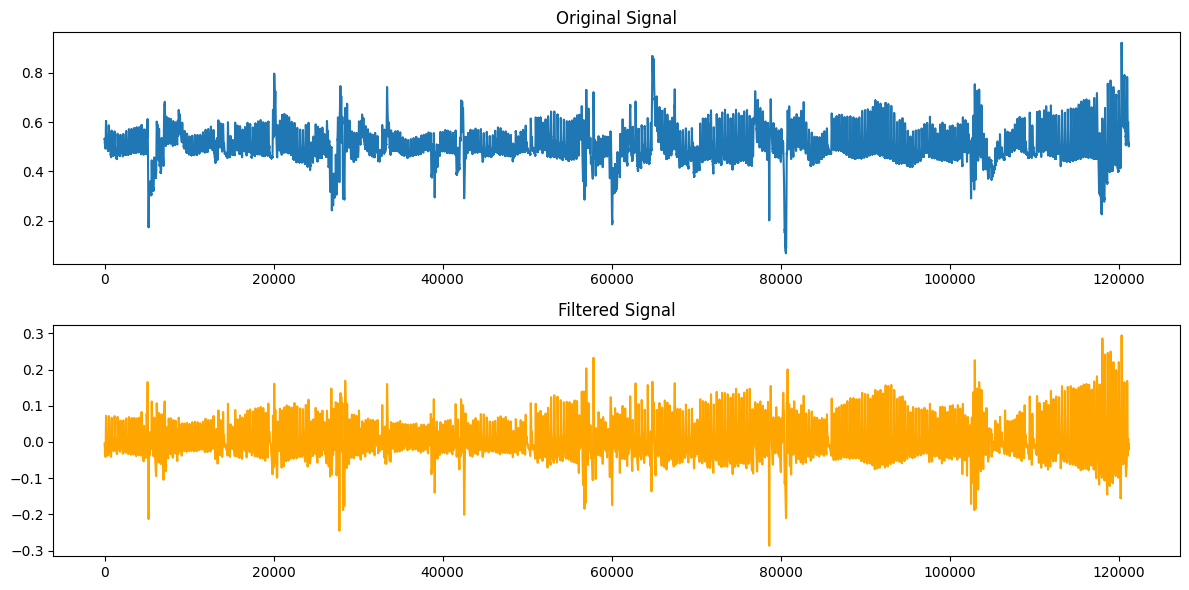

Baseline HRV calculated for 1.
Processing TASK for subject 1, Condition: HighFi from: sub-1_ses-1_task-HighFi_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-01\sub-1_ses-1_task-HighFi\sub-1_ses-1_task-HighFi_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-01\sub-1_ses-1_task-HighFi\sub-1_ses-1_task-HighFi_.xdf.
Calculating task HRV for 1 (full file 484.32s)...


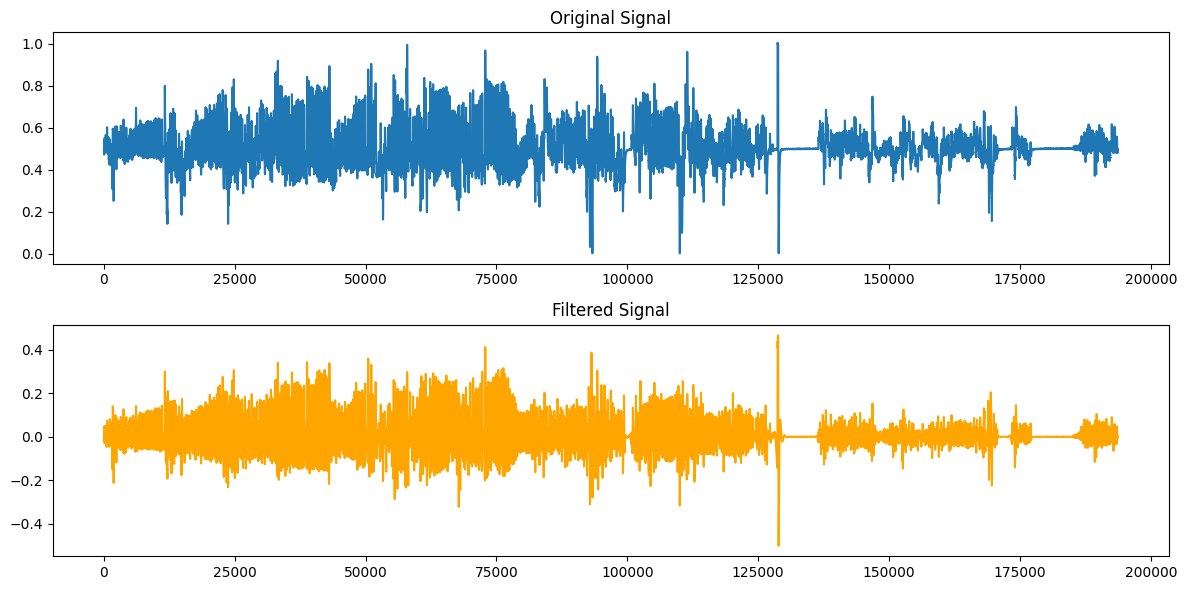

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 1.

Processing session: ses-02
  Found data for subjects in ses-02: ['sub-2']
    Processing data for subject key: sub-2 in session: ses-02
      Found Baseline file: sub-2_ses-2_task-Baseline_.xdf in folder sub-2_ses-2_task-Baseline
      Found Task Condition file: sub-2_ses-1_task-HighFi_.xdf in folder sub-2_ses-2_task-HighFi
      Pair found for 2: Baseline (sub-2_ses-2_task-Baseline_.xdf), Task (sub-2_ses-1_task-HighFi_.xdf)
Processing BASELINE for subject 2 (Experimental Condition: HighFi) from: sub-2_ses-2_task-Baseline_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-02\sub-2_ses-2_task-Baseline\sub-2_ses-2_task-Baseline_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-02\sub-2_ses-2_task-Baseline\sub-2_ses-2_task-Baseline_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocess

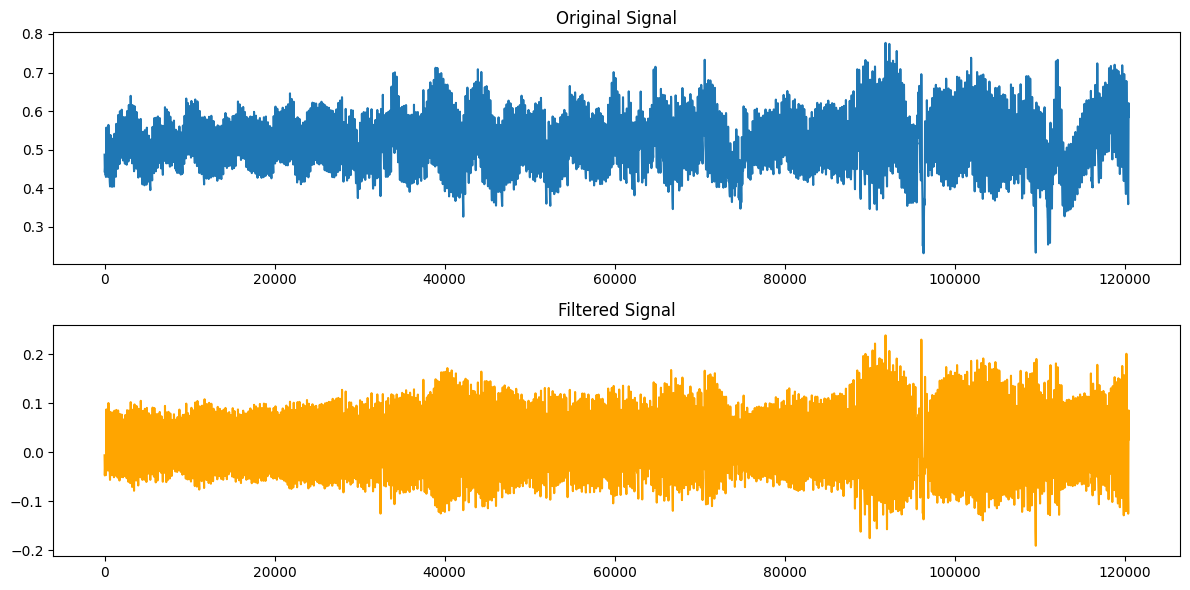

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 2.
Processing TASK for subject 2, Condition: HighFi from: sub-2_ses-1_task-HighFi_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-02\sub-2_ses-2_task-HighFi\sub-2_ses-1_task-HighFi_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-02\sub-2_ses-2_task-HighFi\sub-2_ses-1_task-HighFi_.xdf.
Calculating task HRV for 2 (full file 508.00s)...


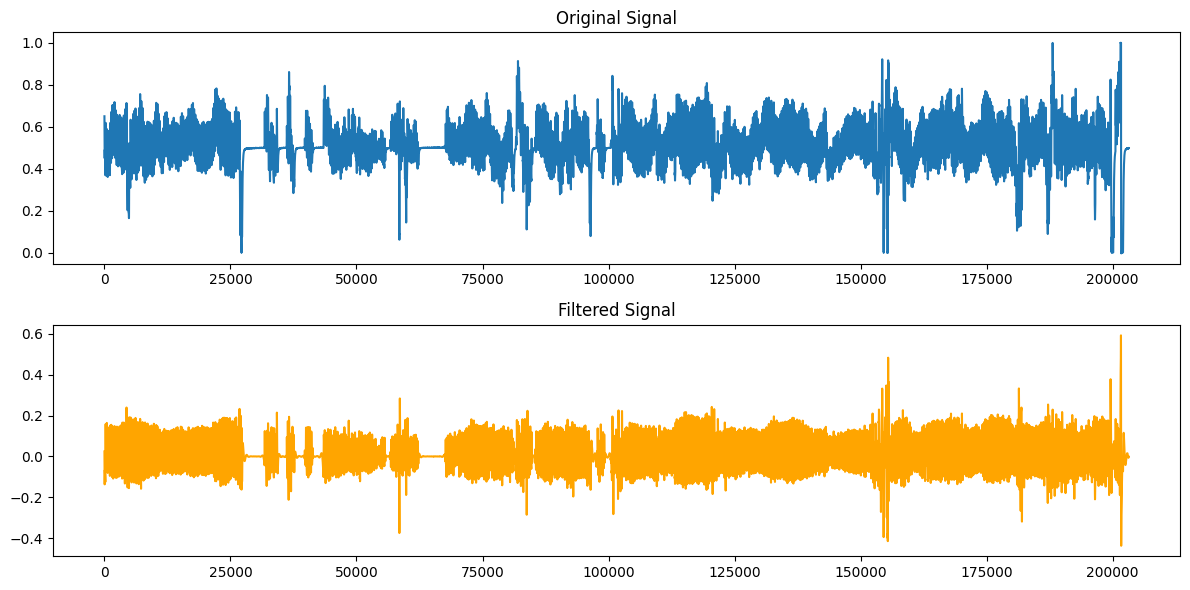

Task HRV calculated for 2.

Processing session: ses-03
  Found data for subjects in ses-03: ['sub-3']
    Processing data for subject key: sub-3 in session: ses-03
      Found Baseline file: sub-3_ses-1_task-Baseline_.xdf in folder sub-3_ses-3_task-Baseline
      Found Task Condition file: sub-3_ses-1_task-MediumFi_.xdf in folder sub-3_ses-3_task-MediumFi
      Pair found for 3: Baseline (sub-3_ses-1_task-Baseline_.xdf), Task (sub-3_ses-1_task-MediumFi_.xdf)
Processing BASELINE for subject 3 (Experimental Condition: MediumFi) from: sub-3_ses-1_task-Baseline_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-03\sub-3_ses-3_task-Baseline\sub-3_ses-1_task-Baseline_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-03\sub-3_ses-3_task-Baseline\sub-3_ses-1_task-Baseline_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dat

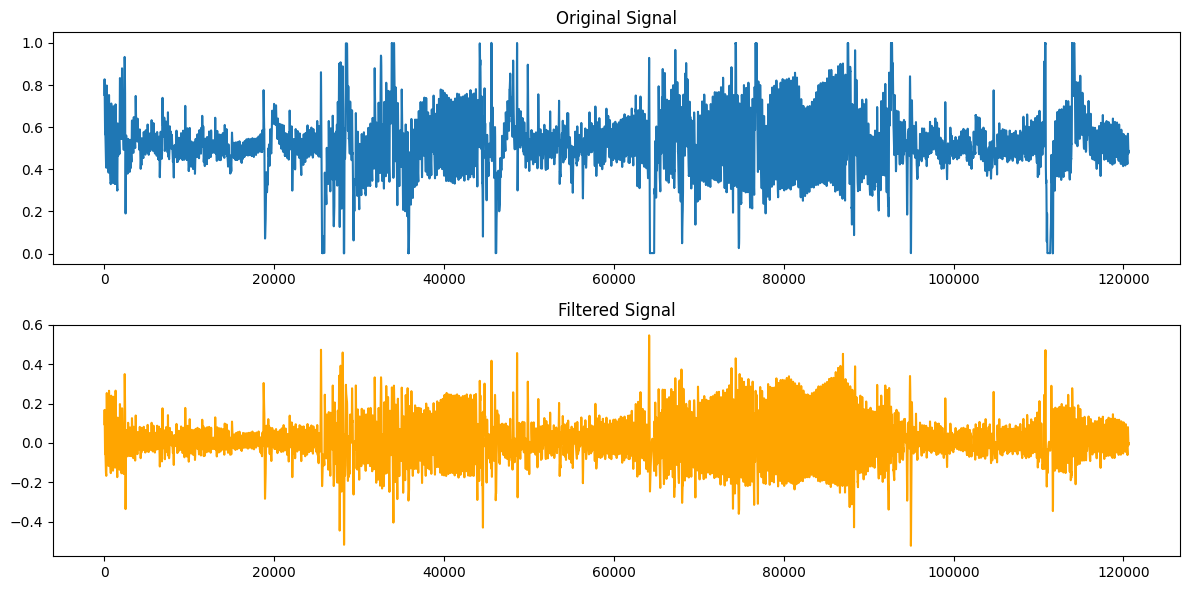

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 3.
Processing TASK for subject 3, Condition: MediumFi from: sub-3_ses-1_task-MediumFi_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-03\sub-3_ses-3_task-MediumFi\sub-3_ses-1_task-MediumFi_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-03\sub-3_ses-3_task-MediumFi\sub-3_ses-1_task-MediumFi_.xdf.
Calculating task HRV for 3 (full file 500.48s)...


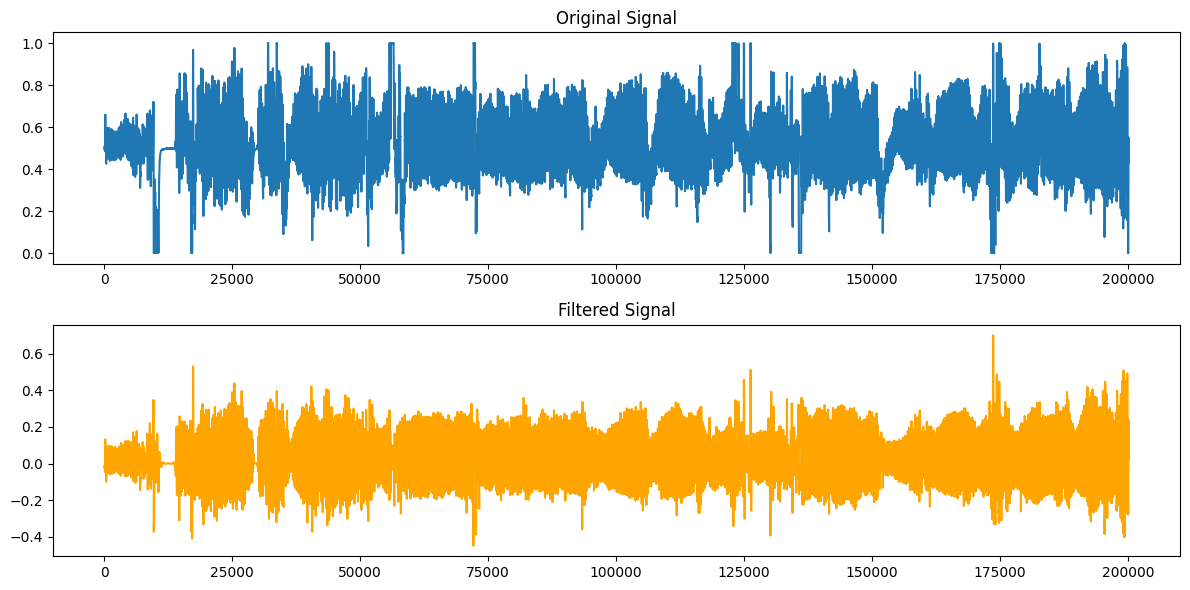

Task HRV calculated for 3.

Processing session: ses-04
  Found data for subjects in ses-04: ['sub-4']
    Processing data for subject key: sub-4 in session: ses-04
      Found Baseline file: sub-4_ses-1_task-Baseline_.xdf in folder sub-4_ses-4_task-Baseline
      Found Task Condition file: sub-4_ses-1_task-HighFi_.xdf in folder sub-4_ses-4_task-HighFi
      Pair found for 4: Baseline (sub-4_ses-1_task-Baseline_.xdf), Task (sub-4_ses-1_task-HighFi_.xdf)
Processing BASELINE for subject 4 (Experimental Condition: HighFi) from: sub-4_ses-1_task-Baseline_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-04\sub-4_ses-4_task-Baseline\sub-4_ses-1_task-Baseline_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-04\sub-4_ses-4_task-Baseline\sub-4_ses-1_task-Baseline_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocess

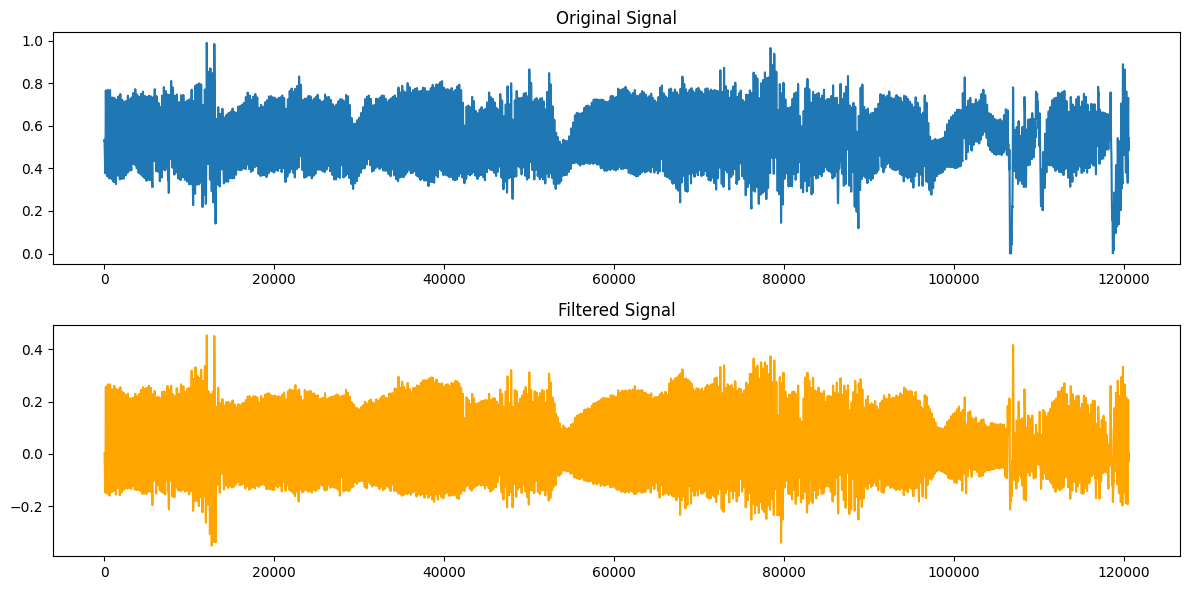

Baseline HRV calculated for 4.
Processing TASK for subject 4, Condition: HighFi from: sub-4_ses-1_task-HighFi_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-04\sub-4_ses-4_task-HighFi\sub-4_ses-1_task-HighFi_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-04\sub-4_ses-4_task-HighFi\sub-4_ses-1_task-HighFi_.xdf.
Calculating task HRV for 4 (full file 412.64s)...


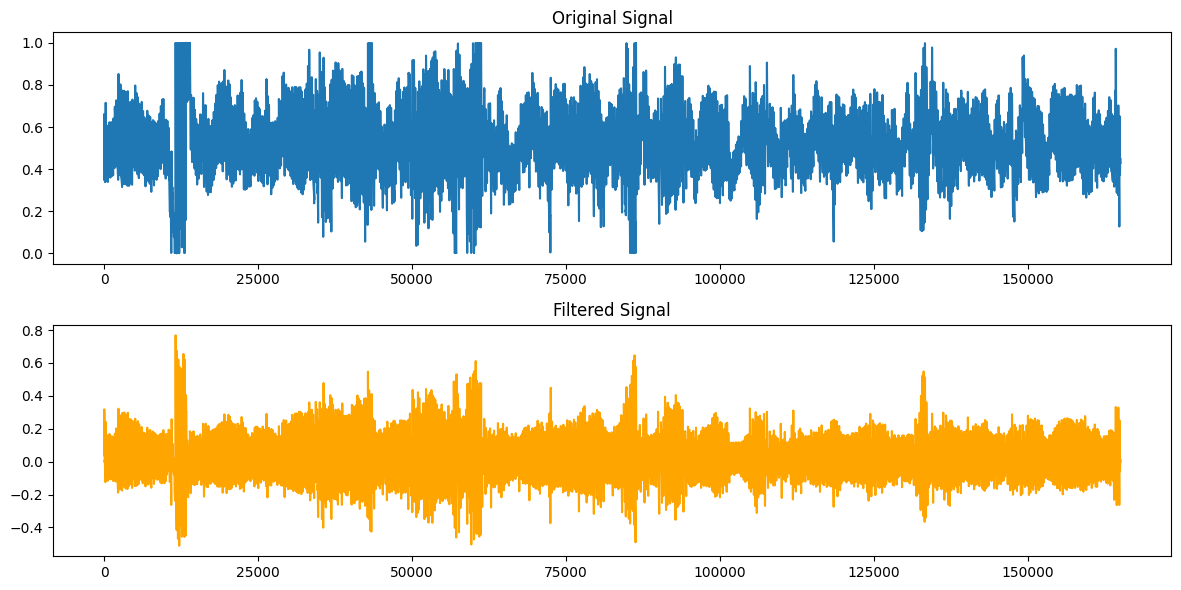

Task HRV calculated for 4.

Processing session: ses-05
  Found data for subjects in ses-05: ['sub-5']
    Processing data for subject key: sub-5 in session: ses-05
      Found Baseline file: sub-5_ses-1_task-Baseline_.xdf in folder sub-5_ses-5_task-Baseline
      Found Task Condition file: sub-5_ses-1_task-HighFi_.xdf in folder sub-5_ses-5_task-HighFi
      Pair found for 5: Baseline (sub-5_ses-1_task-Baseline_.xdf), Task (sub-5_ses-1_task-HighFi_.xdf)
Processing BASELINE for subject 5 (Experimental Condition: HighFi) from: sub-5_ses-1_task-Baseline_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-05\sub-5_ses-5_task-Baseline\sub-5_ses-1_task-Baseline_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-05\sub-5_ses-5_task-Baseline\sub-5_ses-1_task-Baseline_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocess

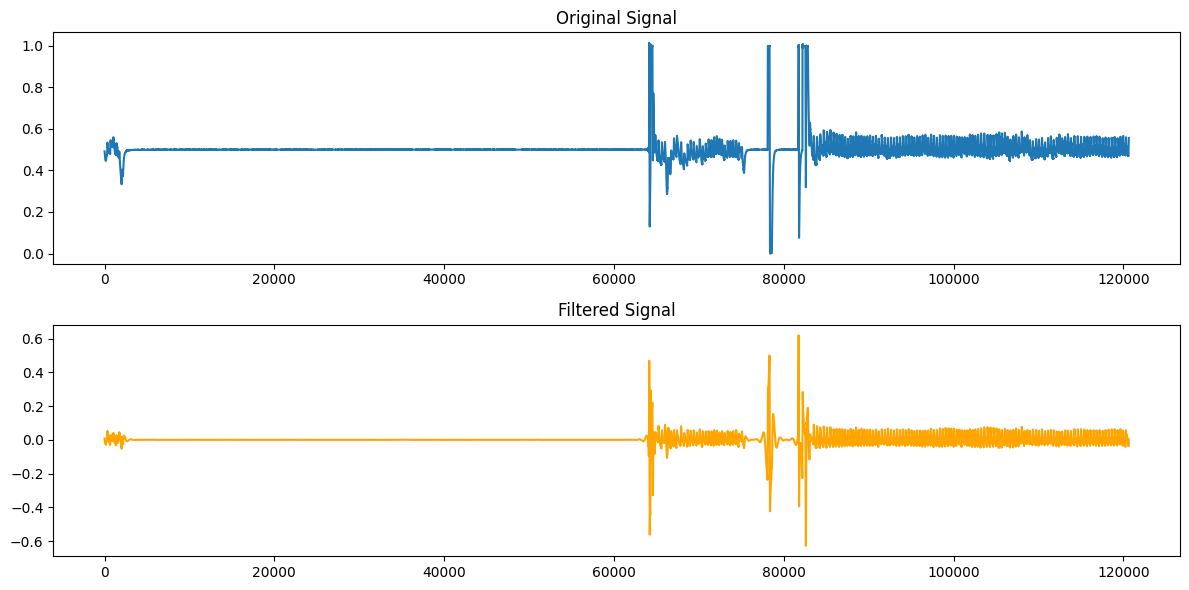

Error processing segment: 
----------------
Could not determine best fit for given signal. Please check the source signal.
 Probable causes:
- detected heart rate falls outside of bpmmin<->bpmmax constraints
- no detectable heart rate present in signal
- very noisy signal (consider filtering and scaling)
If you're sure the signal contains heartrate data, consider filtering and/or scaling first.
----------------

No HRV metrics obtained for baseline for subject 5.
Processing TASK for subject 5, Condition: HighFi from: sub-5_ses-1_task-HighFi_.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-05\sub-5_ses-5_task-HighFi\sub-5_ses-1_task-HighFi_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-05\sub-5_ses-5_task-HighFi\sub-5_ses-1_task-HighFi_.xdf.
Calculating task HRV for 5 (full file 491.04s)...


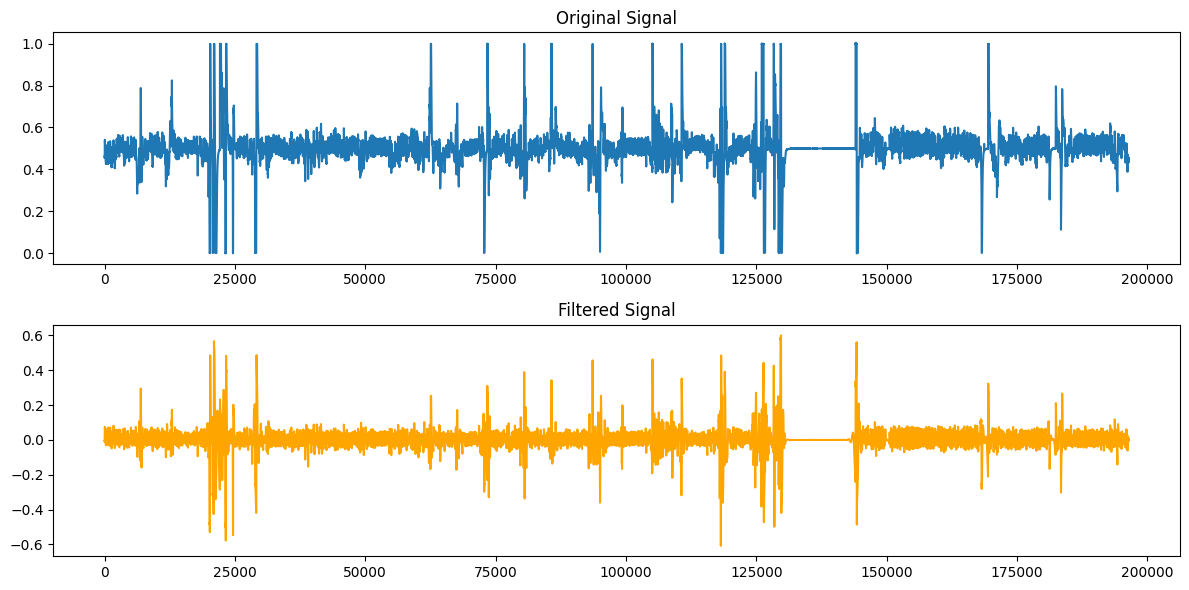

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 5.

Processing session: ses-06
  Found data for subjects in ses-06: ['sub-6']
    Processing data for subject key: sub-6 in session: ses-06
      Found Baseline file: _.xdf in folder sub-6_ses-6_task-Baseline
      Found Task Condition file: _.xdf in folder sub-6_ses-6_task-MediumFi
      Pair found for 6: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 6 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-06\sub-6_ses-6_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-06\sub-6_ses-6_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-06\sub-6_ses-6_task-Baseline\_.xdf.
Calculating baseline HRV for 6 (full file)...


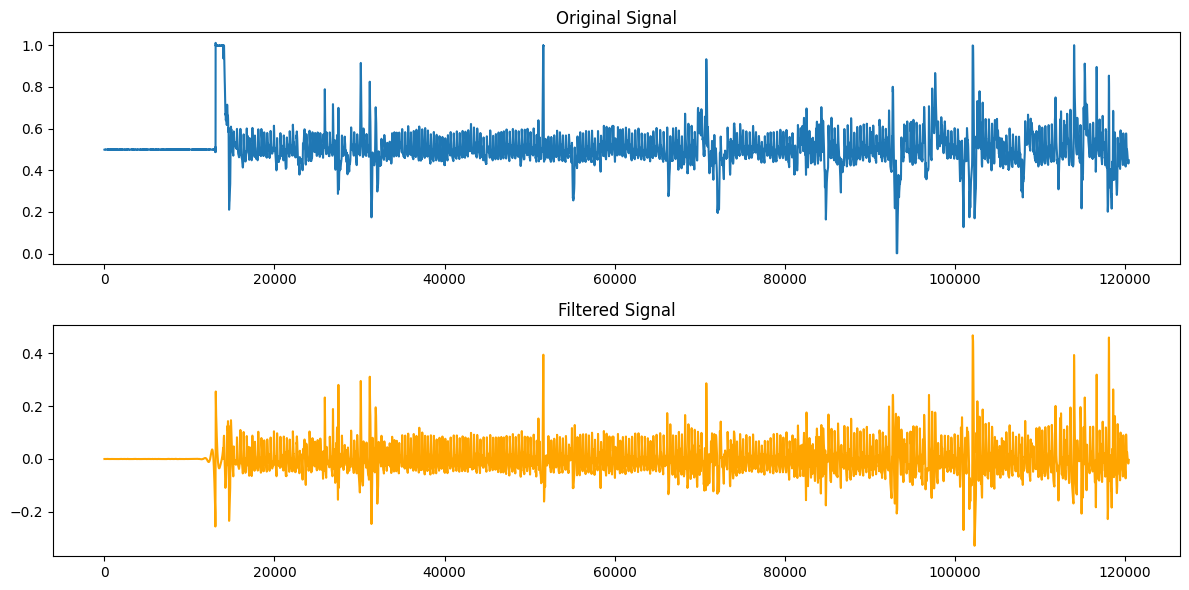

Baseline HRV calculated for 6.
Processing TASK for subject 6, Condition: MediumFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-06\sub-6_ses-6_task-MediumFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-06\sub-6_ses-6_task-MediumFi\_.xdf.
Calculating task HRV for 6 (full file 510.56s)...


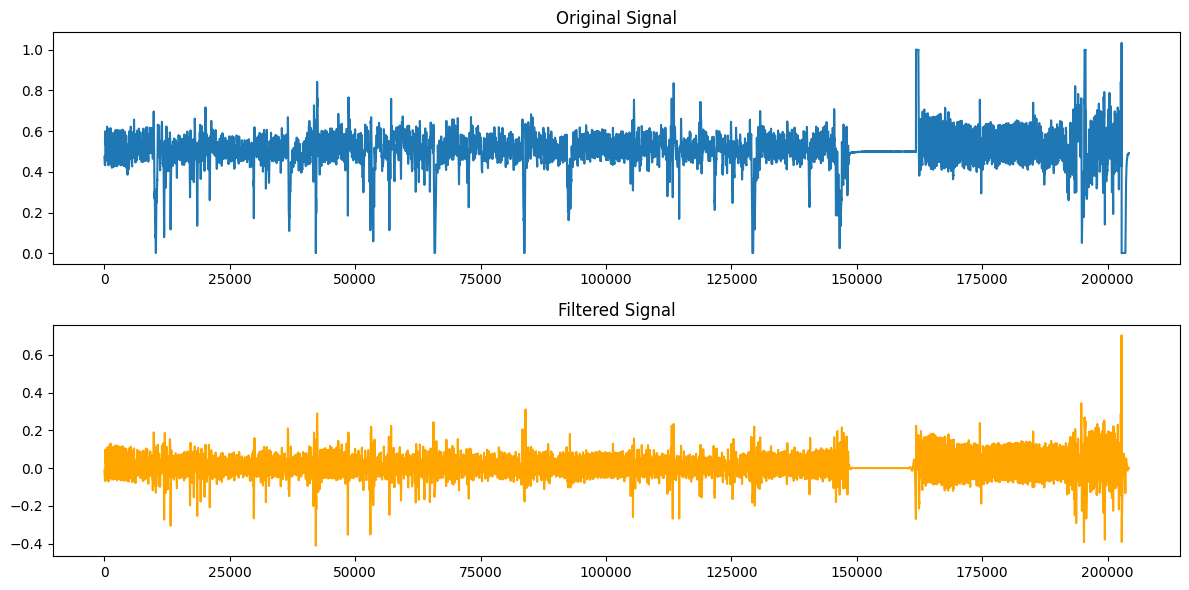

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 6.

Processing session: ses-07
  Found data for subjects in ses-07: ['sub-7']
    Processing data for subject key: sub-7 in session: ses-07
      Found Baseline file: _.xdf in folder sub-7_ses-7_task-Baseline
      Found Task Condition file: _.xdf in folder sub-7_ses-7_task-LowFi
      Pair found for 7: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 7 (Experimental Condition: LowFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-07\sub-7_ses-7_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-07\sub-7_ses-7_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-07\sub-7_ses-7_task-Baseline\_.xdf.
Calculating baseline HRV for 7 (full file)...


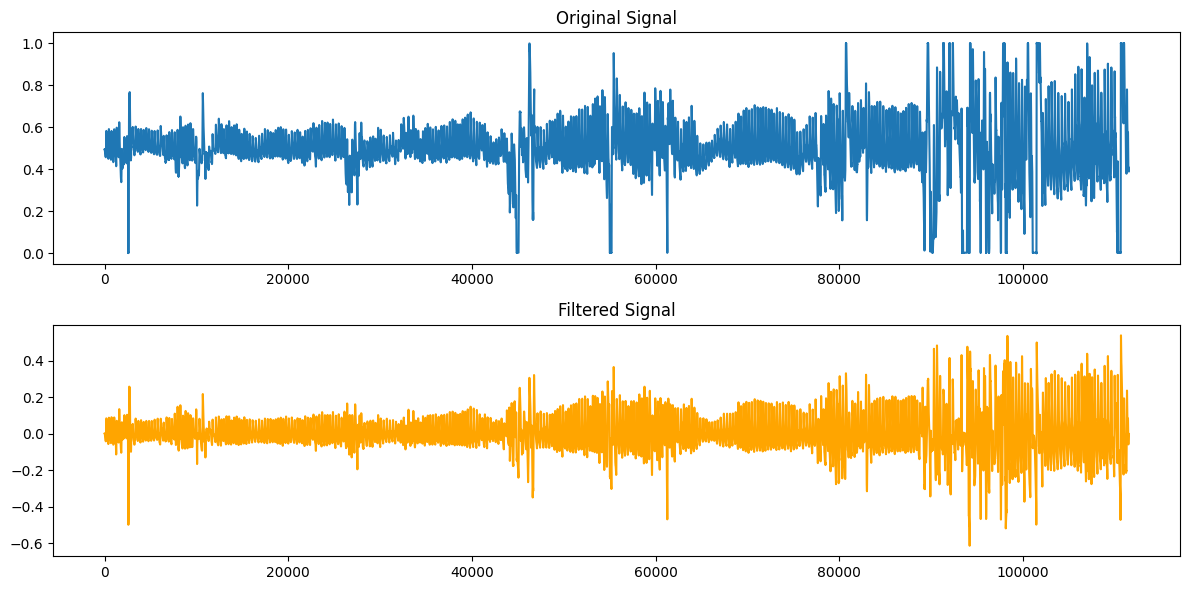

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 7.
Processing TASK for subject 7, Condition: LowFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-07\sub-7_ses-7_task-LowFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-07\sub-7_ses-7_task-LowFi\_.xdf.
Calculating task HRV for 7 (full file 451.92s)...


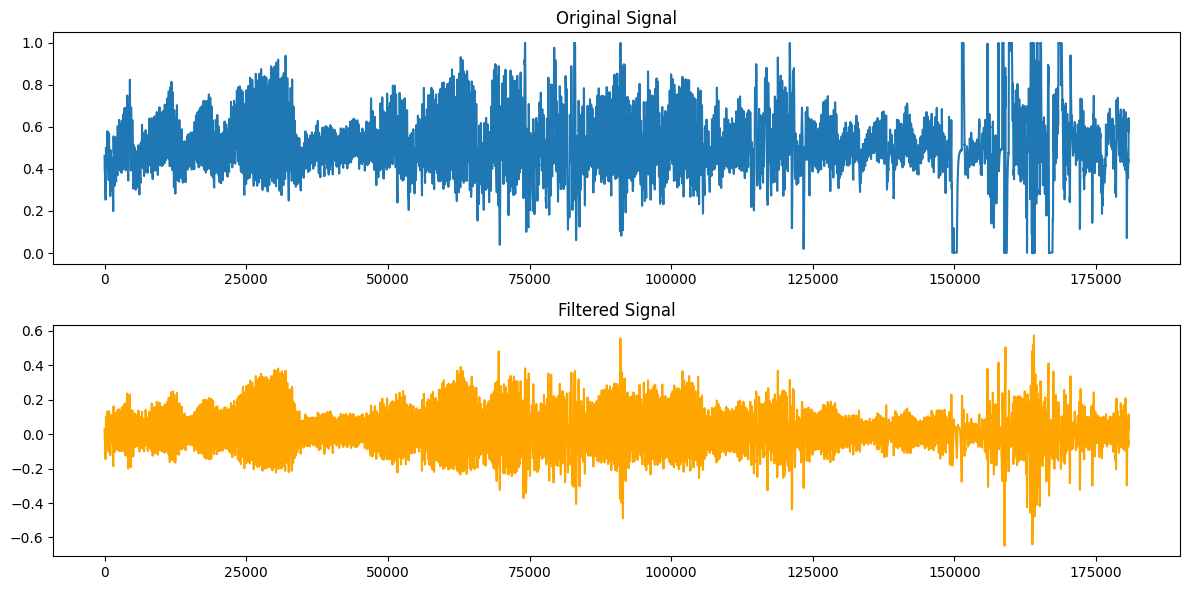

Task HRV calculated for 7.

Processing session: ses-08
  Found data for subjects in ses-08: ['sub-8']
    Processing data for subject key: sub-8 in session: ses-08
      Found Baseline file: _.xdf in folder sub-8_ses-8_task-Baseline
      Found Task Condition file: _.xdf in folder sub-8_ses-8_task-HighFi
      Pair found for 8: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 8 (Experimental Condition: HighFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-08\sub-8_ses-8_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-08\sub-8_ses-8_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-08\sub-8_ses-8_task-Baseline\_.xdf.
Calculating baseline HRV for 8 (full file)...


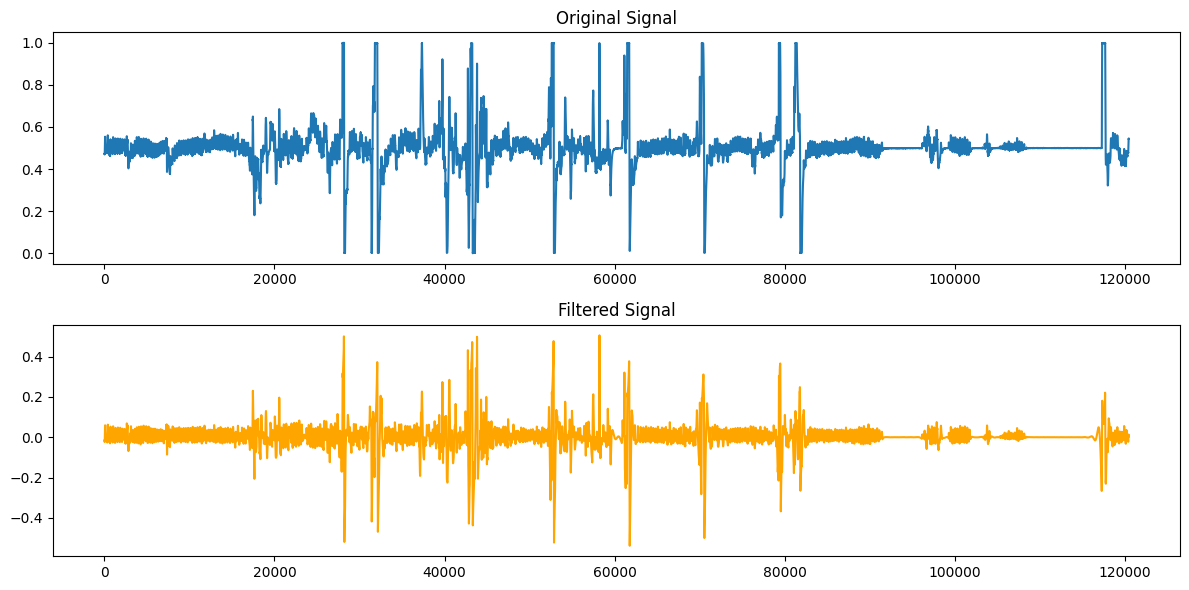

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 8.
Processing TASK for subject 8, Condition: HighFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-08\sub-8_ses-8_task-HighFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-08\sub-8_ses-8_task-HighFi\_.xdf.
Calculating task HRV for 8 (full file 510.56s)...


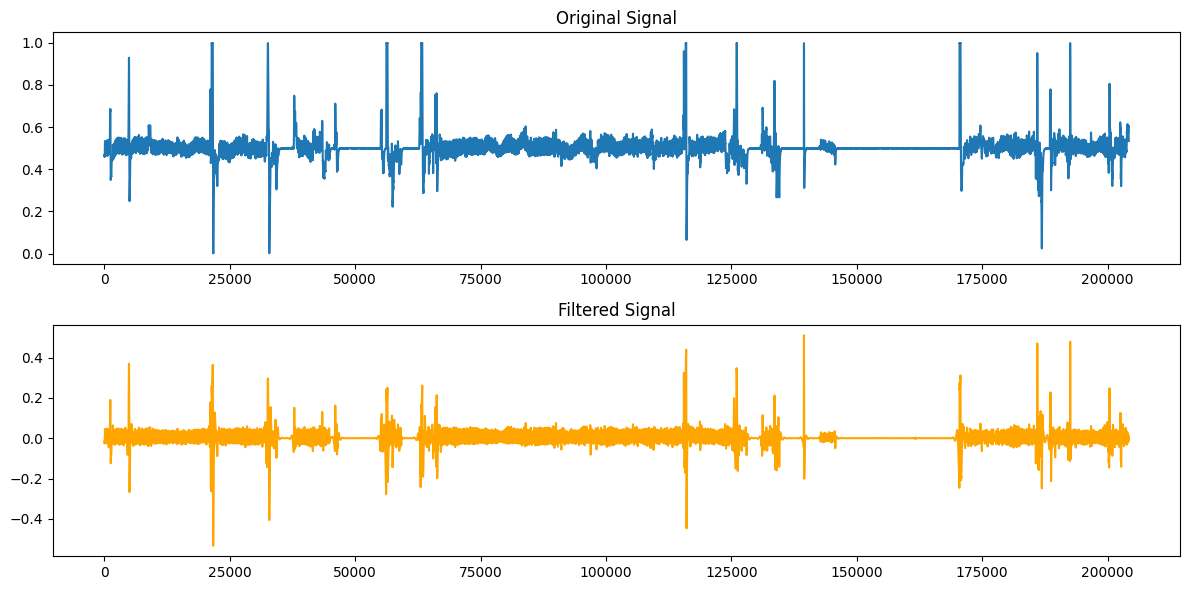

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 8.

Processing session: ses-09
  Found data for subjects in ses-09: ['sub-9']
    Processing data for subject key: sub-9 in session: ses-09
      Found Baseline file: _.xdf in folder sub-9_ses-9_task-Baseline
      Found Task Condition file: _.xdf in folder sub-9_ses-9_task-MediumFi
      Pair found for 9: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 9 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-09\sub-9_ses-9_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-09\sub-9_ses-9_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-09\sub-9_ses-9_task-Baseline\_.xdf.
Calculating baseline HRV for 9 (full file)...


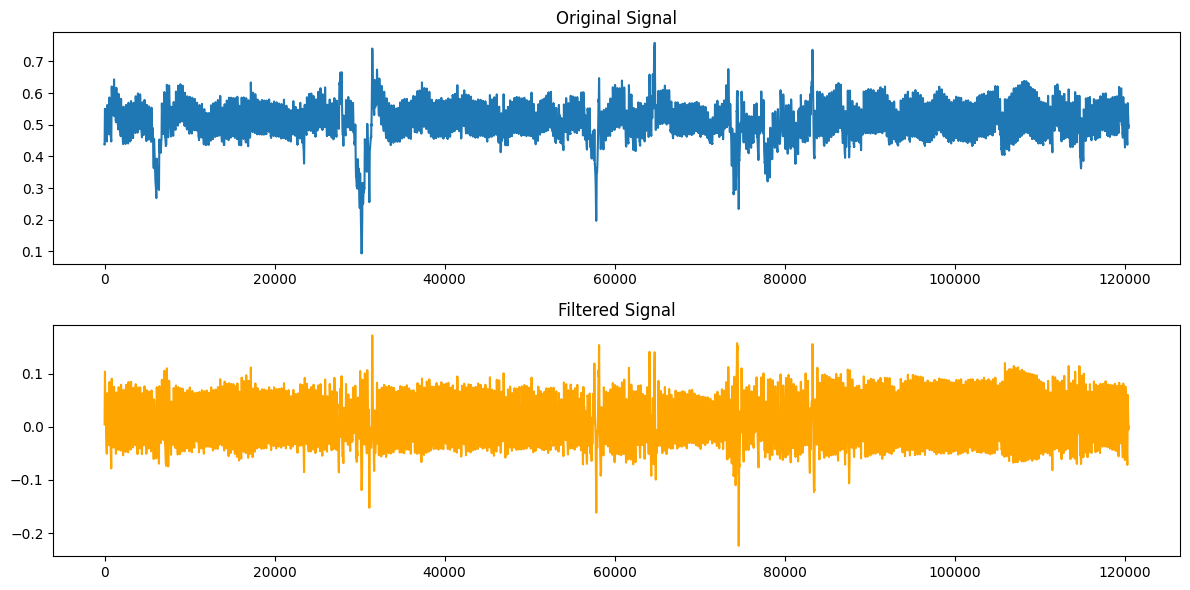

Baseline HRV calculated for 9.
Processing TASK for subject 9, Condition: MediumFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-09\sub-9_ses-9_task-MediumFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-09\sub-9_ses-9_task-MediumFi\_.xdf.
Calculating task HRV for 9 (full file 520.64s)...


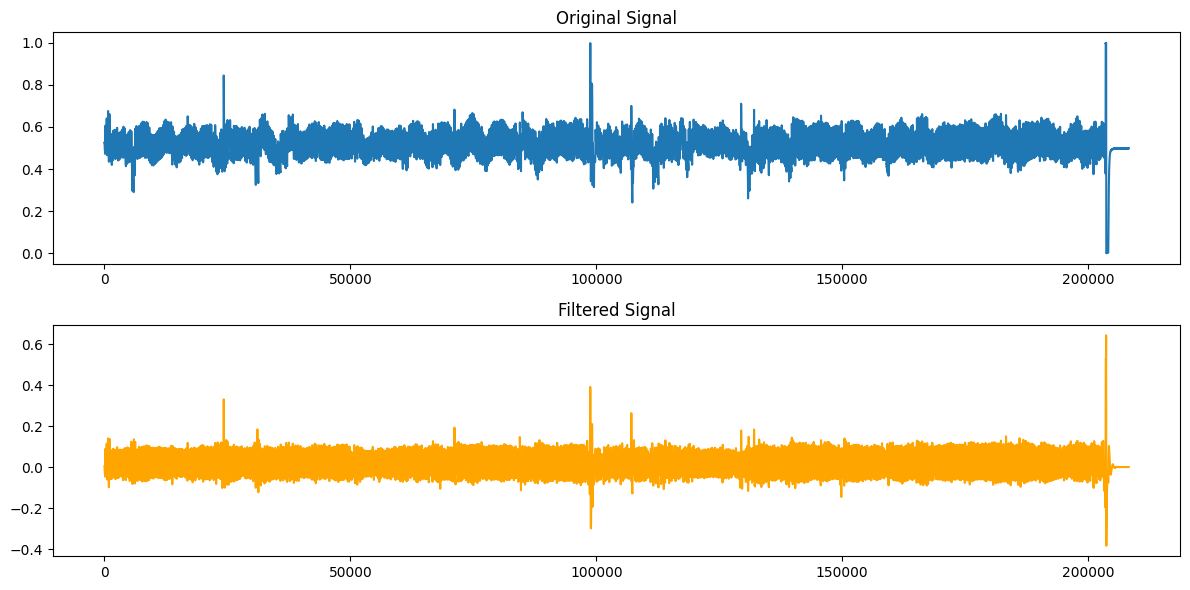

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 9.

Processing session: ses-10
  Found data for subjects in ses-10: ['sub-10']
    Processing data for subject key: sub-10 in session: ses-10
      Found Baseline file: _.xdf in folder sub-10_ses-10_task-Baseline
      Found Task Condition file: _.xdf in folder sub-10_ses-10_task-MediumFi
      Pair found for 10: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 10 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-10\sub-10_ses-10_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-10\sub-10_ses-10_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-10\sub-10_ses-10_task-Baseline\_.xdf.
Calculating baseline HRV for 10 (full file)...


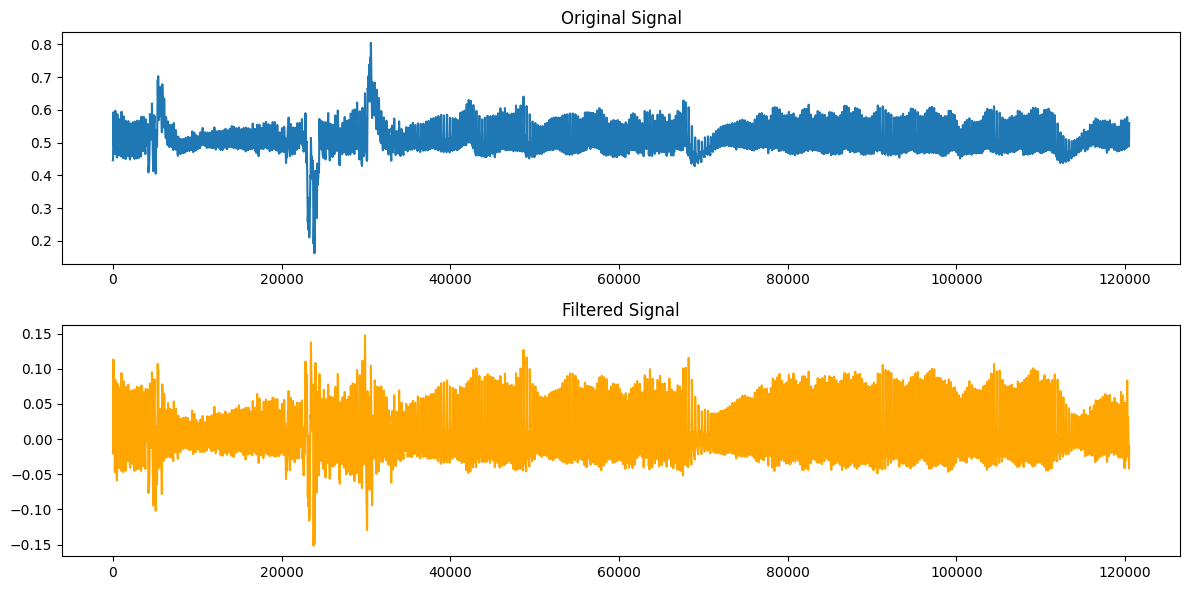

Baseline HRV calculated for 10.
Processing TASK for subject 10, Condition: MediumFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-10\sub-10_ses-10_task-MediumFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-10\sub-10_ses-10_task-MediumFi\_.xdf.
Calculating task HRV for 10 (full file 528.56s)...


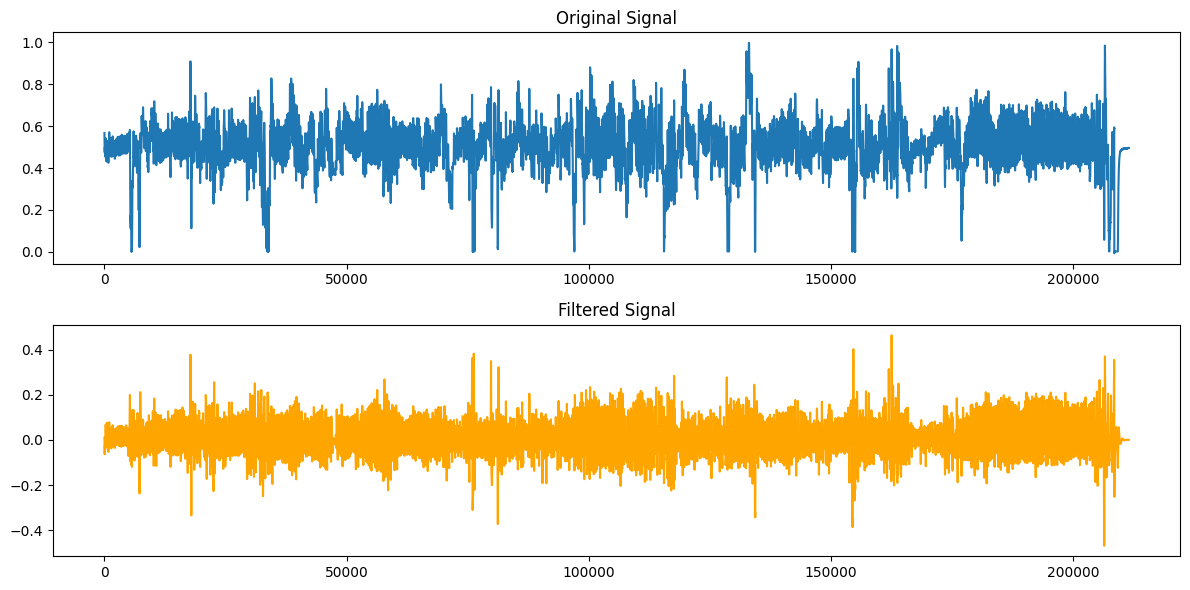

Task HRV calculated for 10.

Processing session: ses-11
  Found data for subjects in ses-11: ['sub-11']
    Processing data for subject key: sub-11 in session: ses-11
      Found Baseline file: _.xdf in folder sub-11_ses-11_task-Baseline
      Found Task Condition file: _.xdf in folder sub-11_ses-11_task-LowFi
      Pair found for 11: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 11 (Experimental Condition: LowFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-11\sub-11_ses-11_task-Baseline\_.xdf
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-11\sub-11_ses-11_task-Baseline\_.xdf.
Could not process BVP for baseline for subject 11 from _.xdf.
Processing TASK for subject 11, Condition: LowFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-11\sub-11_ses-11_task-LowFi\_.xdf
C

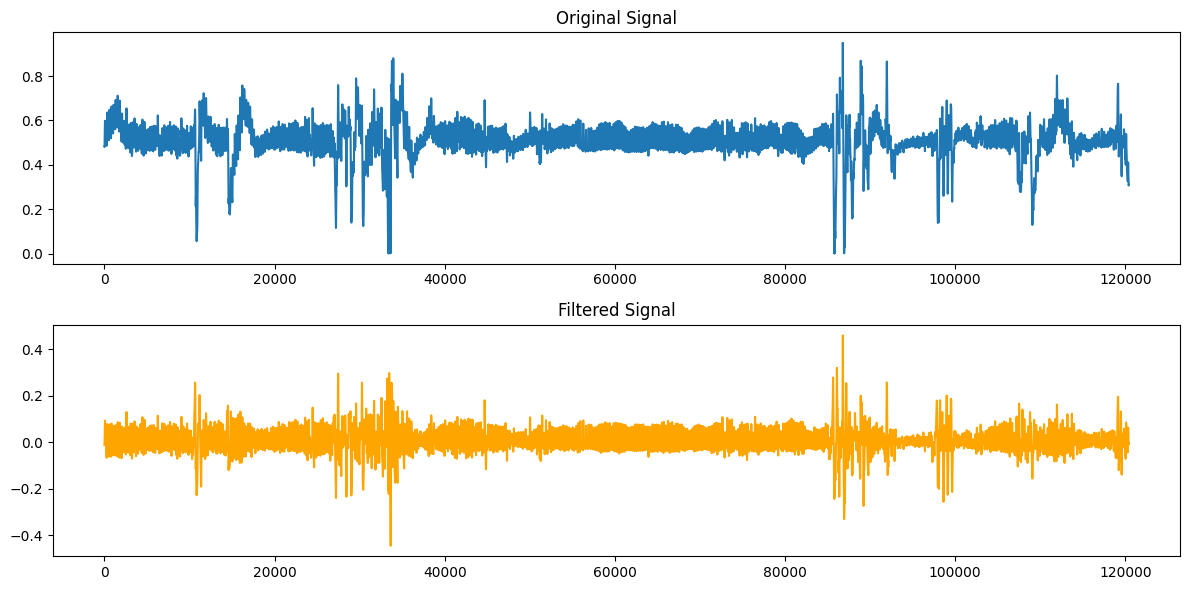

Baseline HRV calculated for 16.
Processing TASK for subject 16, Condition: LowFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-16\sub-16_ses-16_task-LowFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-16\sub-16_ses-16_task-LowFi\_.xdf.
Calculating task HRV for 16 (full file 489.12s)...


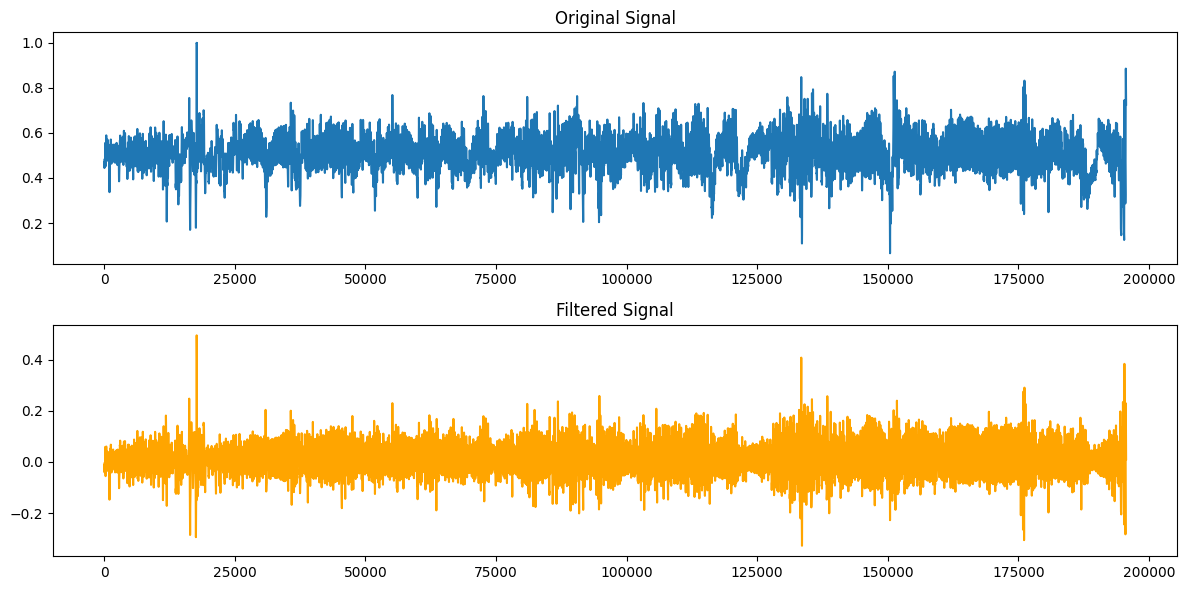

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 16.

Processing session: ses-17
  Found data for subjects in ses-17: ['sub-17']
    Processing data for subject key: sub-17 in session: ses-17
      Found Baseline file: _.xdf in folder sub-17_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-17_ses-1_task-LowFi
      Pair found for 17: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 17 (Experimental Condition: LowFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-17\sub-17_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-17\sub-17_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-17\sub-17_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 17 (full file)...


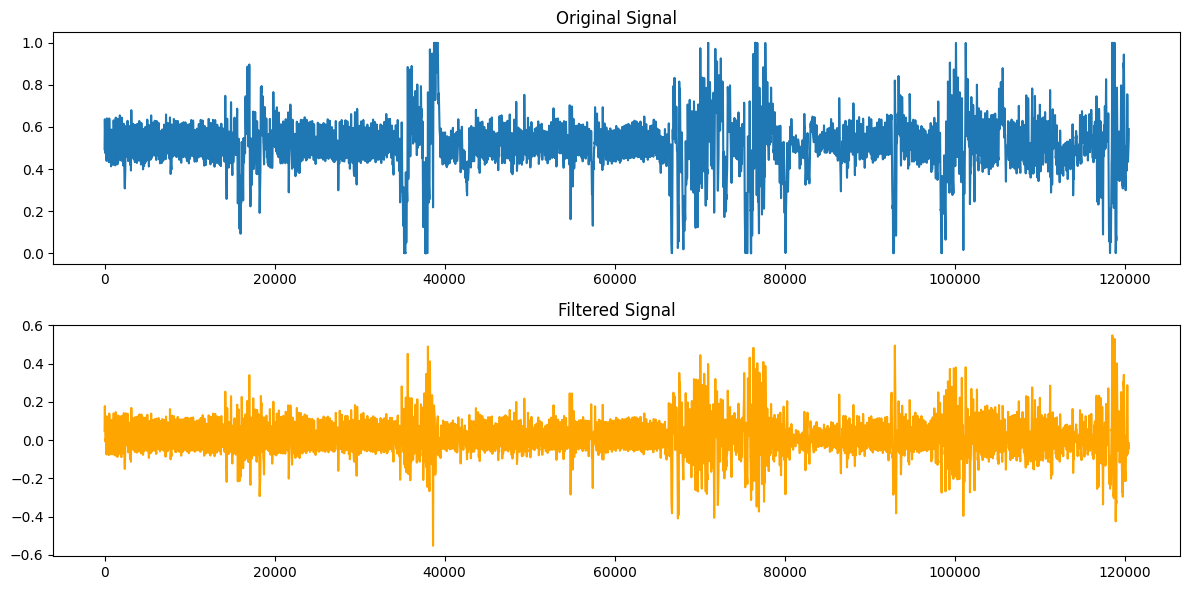

Baseline HRV calculated for 17.
Processing TASK for subject 17, Condition: LowFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-17\sub-17_ses-1_task-LowFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-17\sub-17_ses-1_task-LowFi\_.xdf.
Calculating task HRV for 17 (full file 504.00s)...


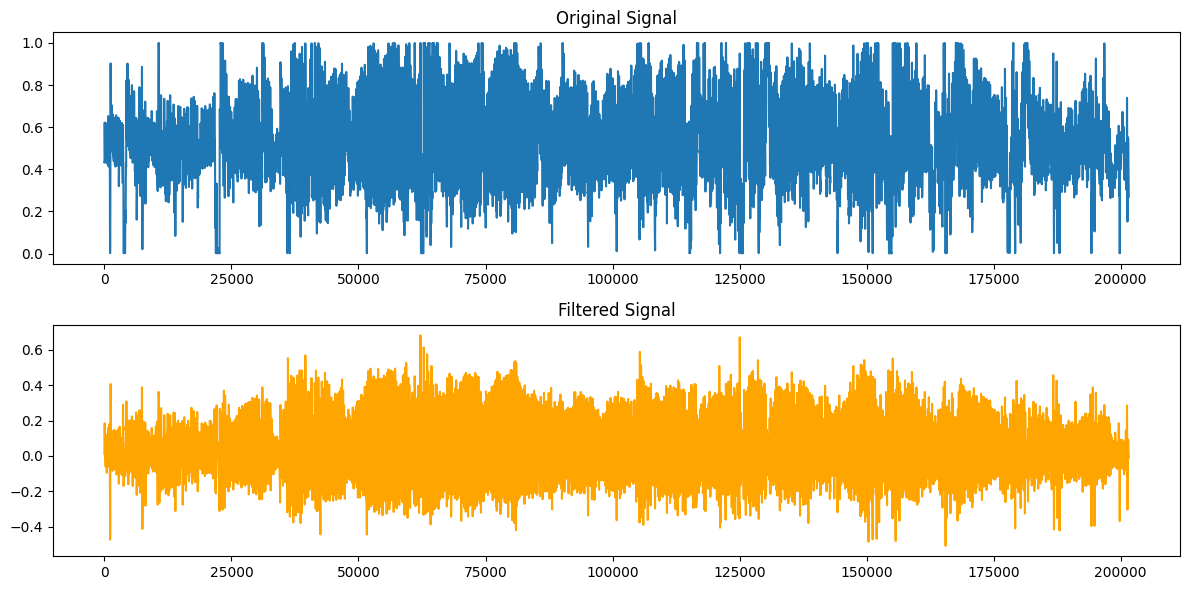

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 17.

Processing session: ses-18
  Found data for subjects in ses-18: ['sub-18']
    Processing data for subject key: sub-18 in session: ses-18
      Found Baseline file: _.xdf in folder sub-18_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-18_ses-1_task-HighFi
      Pair found for 18: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 18 (Experimental Condition: HighFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-18\sub-18_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-18\sub-18_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-18\sub-18_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 18 (full file)...


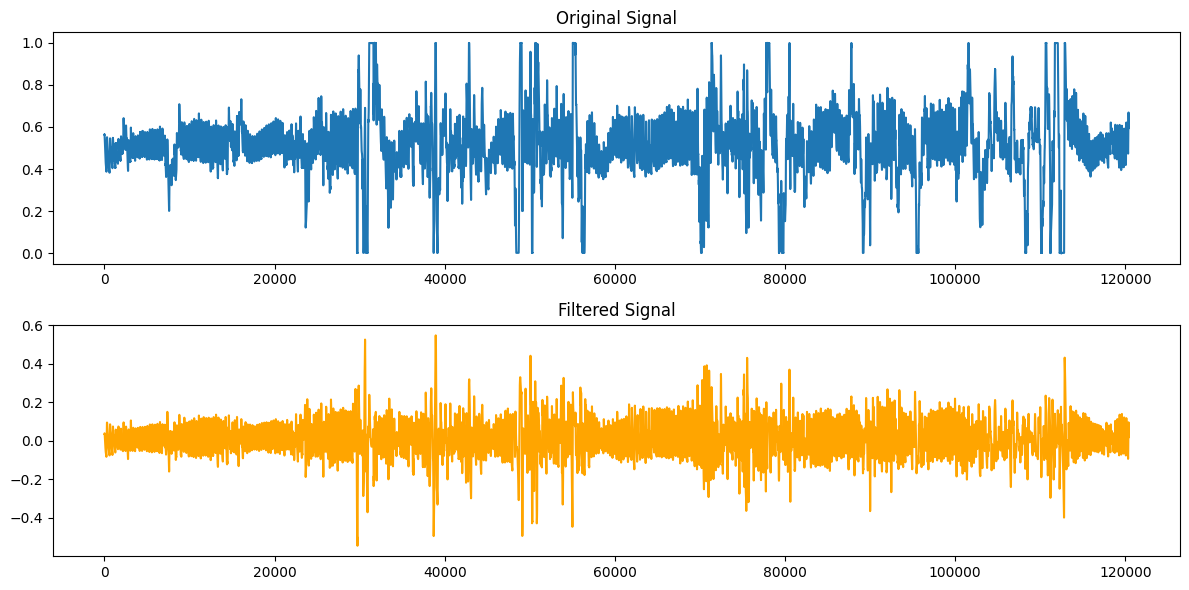

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 18.
Processing TASK for subject 18, Condition: HighFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-18\sub-18_ses-1_task-HighFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-18\sub-18_ses-1_task-HighFi\_.xdf.
Calculating task HRV for 18 (full file 750.88s)...


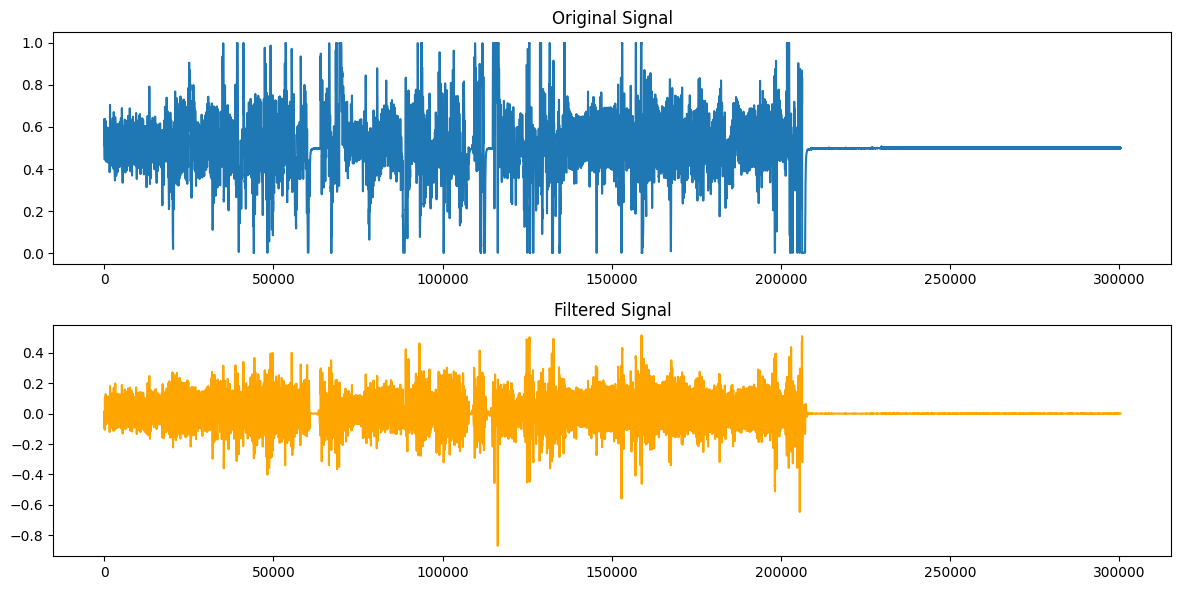

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 18.

Processing session: ses-19
  Found data for subjects in ses-19: ['sub-19']
    Processing data for subject key: sub-19 in session: ses-19
      Found Baseline file: _.xdf in folder sub-19_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-19_ses-1_task-MediumFi
      Pair found for 19: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 19 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-19\sub-19_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-19\sub-19_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-19\sub-19_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 19 (full file)...
No HRV metrics obtained for baseline for subjec

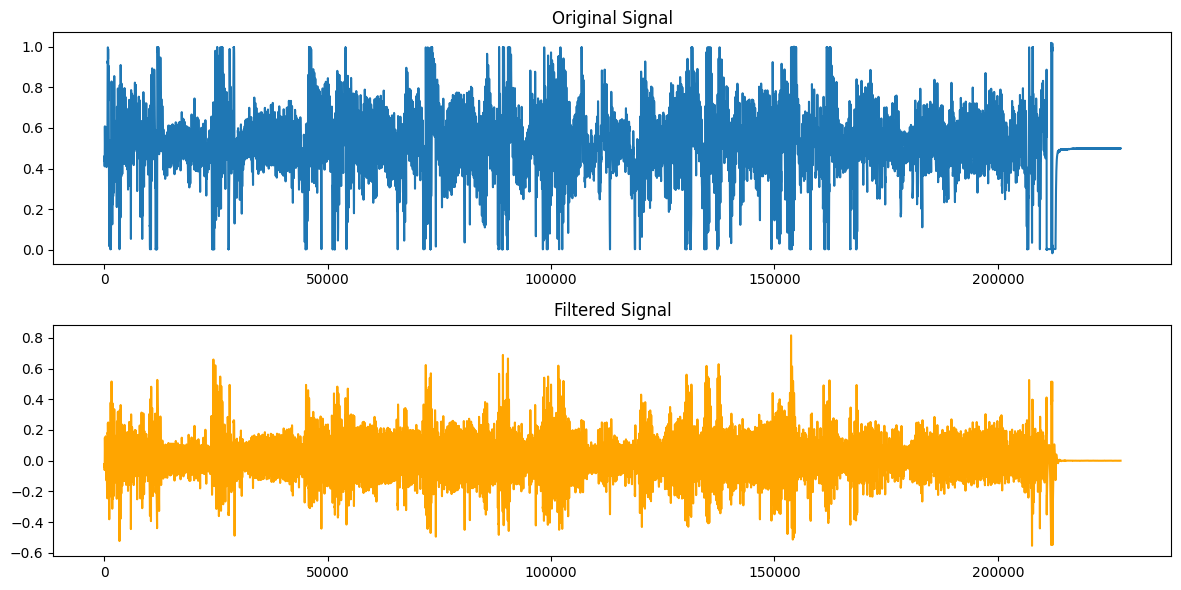

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 19.

Processing session: ses-20
  Found data for subjects in ses-20: ['sub-20']
    Processing data for subject key: sub-20 in session: ses-20
      Found Baseline file: _.xdf in folder sub-20_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-20_ses-1_task-LowFi
      Pair found for 20: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 20 (Experimental Condition: LowFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-20\sub-20_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-20\sub-20_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-20\sub-20_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 20 (full file)...


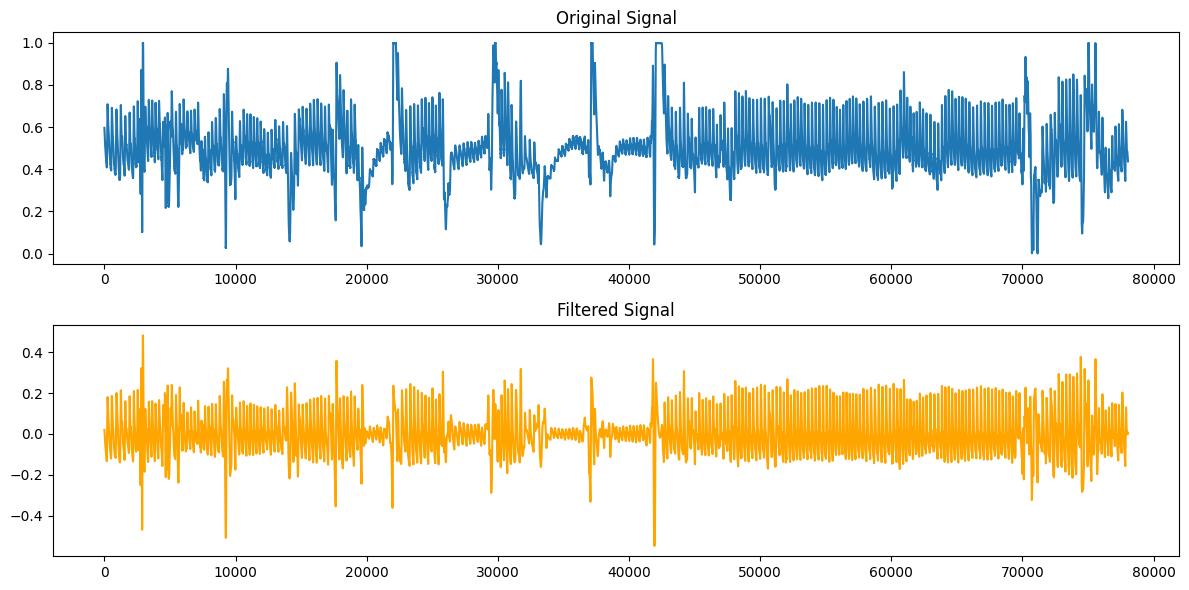

Baseline HRV calculated for 20.
Processing TASK for subject 20, Condition: LowFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-20\sub-20_ses-1_task-LowFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-20\sub-20_ses-1_task-LowFi\_.xdf.
Calculating task HRV for 20 (full file 471.36s)...


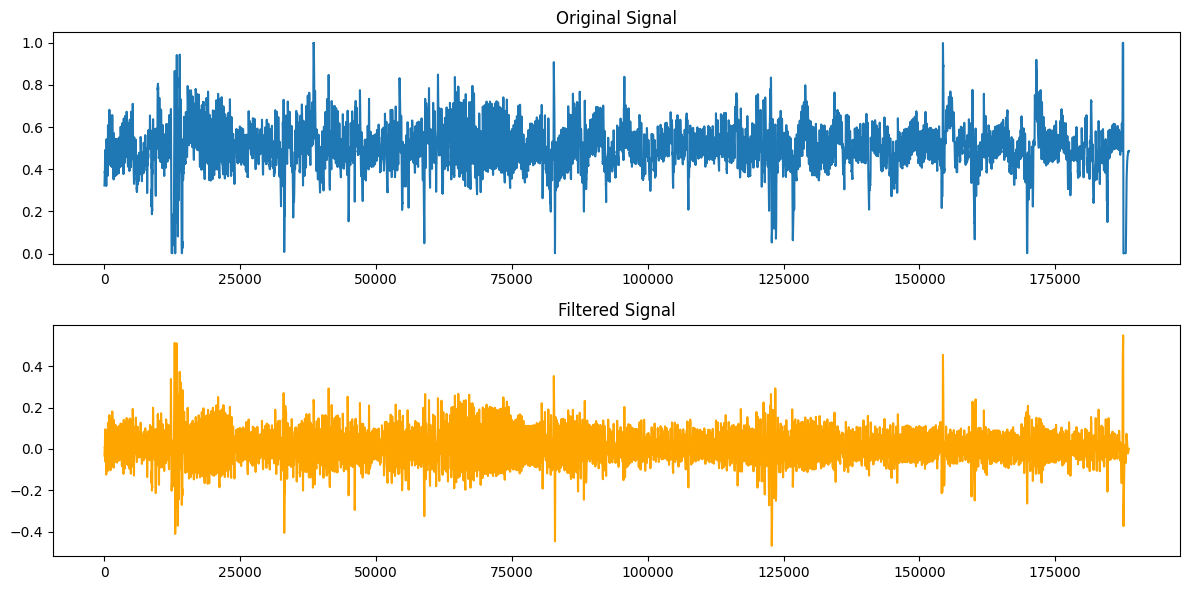

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 20.

Processing session: ses-21
  Found data for subjects in ses-21: ['sub-21']
    Processing data for subject key: sub-21 in session: ses-21
      Found Baseline file: _.xdf in folder sub-21_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-21_ses-1_task-HighFi
      Pair found for 21: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 21 (Experimental Condition: HighFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-21\sub-21_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-21\sub-21_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-21\sub-21_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 21 (full file)...


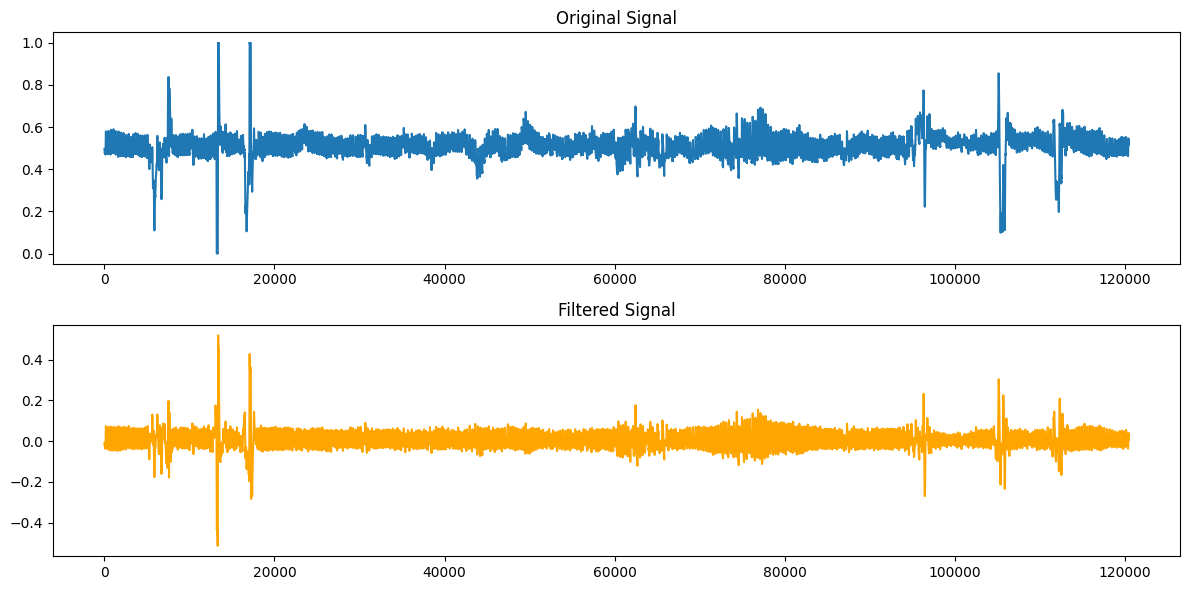

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 21.
Processing TASK for subject 21, Condition: HighFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-21\sub-21_ses-1_task-HighFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-21\sub-21_ses-1_task-HighFi\_.xdf.
Calculating task HRV for 21 (full file 491.52s)...


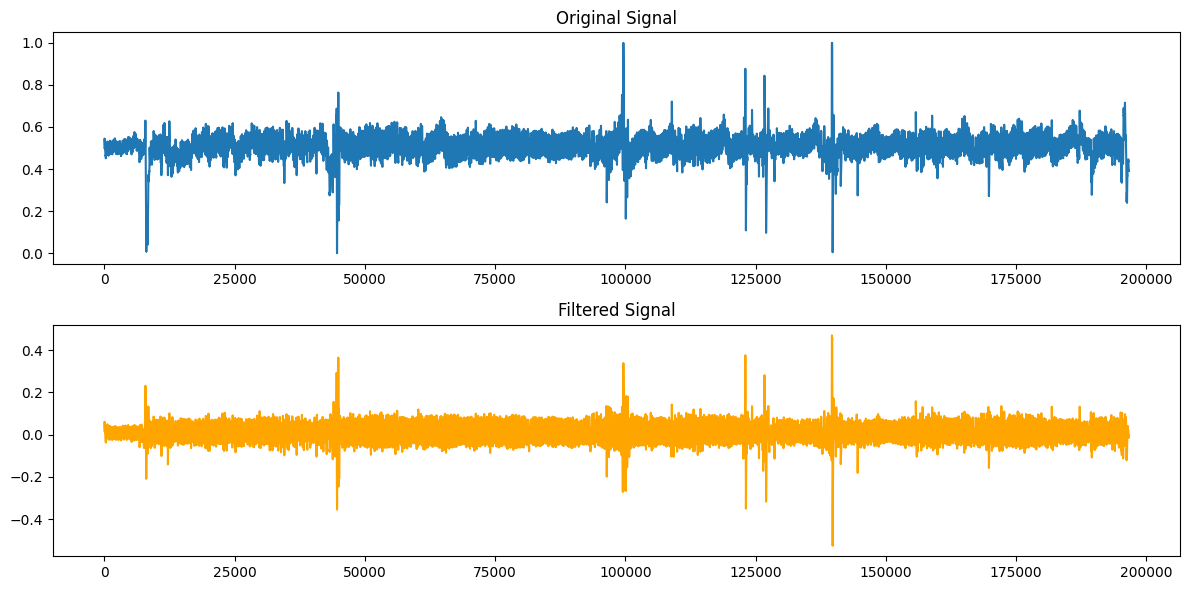

Task HRV calculated for 21.

Processing session: ses-22
  Found data for subjects in ses-22: ['sub-22']
    Processing data for subject key: sub-22 in session: ses-22
      Found Baseline file: _.xdf in folder sub-22_ses-22_task-Baseline
      Found Task Condition file: _.xdf in folder sub-22_ses-22_task-MediumFi
      Pair found for 22: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 22 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-22\sub-22_ses-22_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-22\sub-22_ses-22_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-22\sub-22_ses-22_task-Baseline\_.xdf.
Calculating baseline HRV for 22 (full file)...


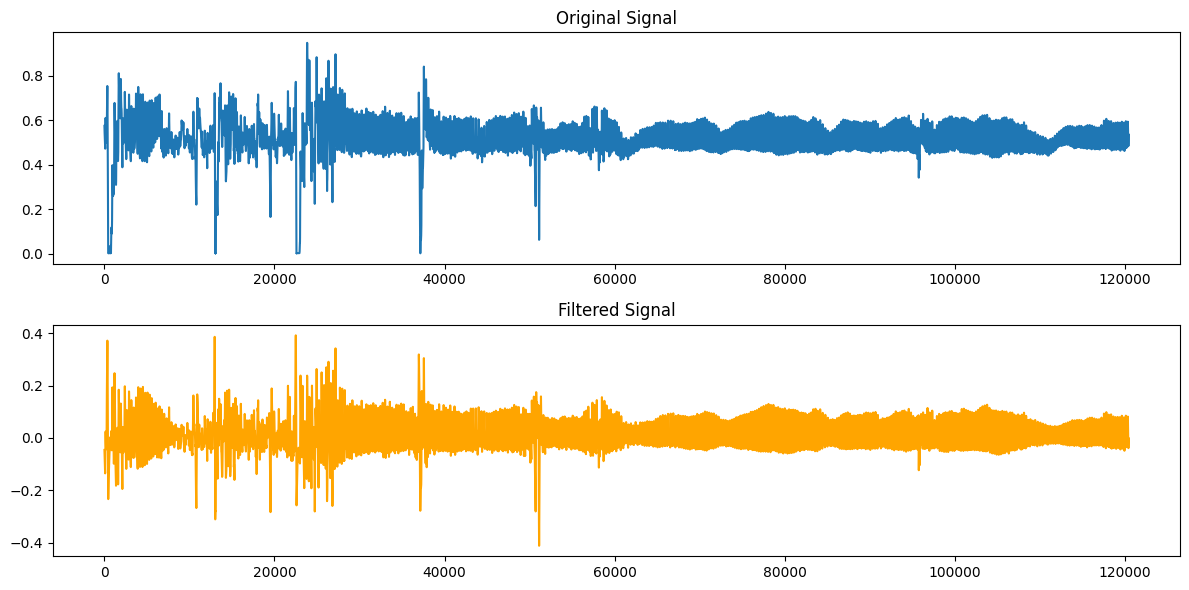

Baseline HRV calculated for 22.
Processing TASK for subject 22, Condition: MediumFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-22\sub-22_ses-22_task-MediumFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-22\sub-22_ses-22_task-MediumFi\_.xdf.
Calculating task HRV for 22 (full file 512.40s)...


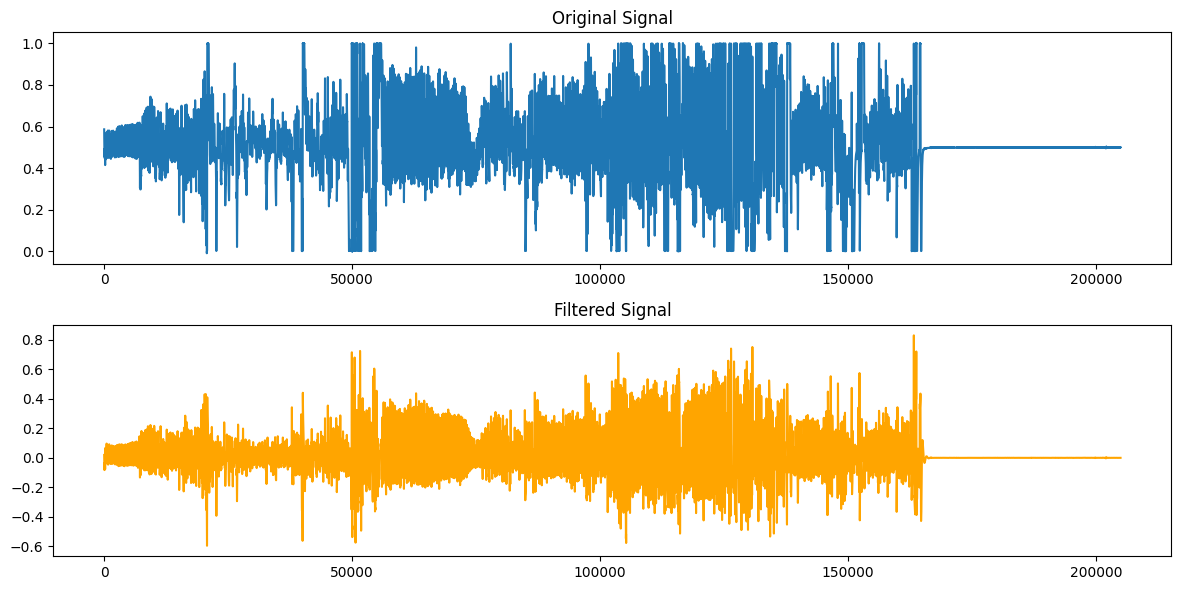

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 22.

Processing session: ses-23
  Found data for subjects in ses-23: ['sub-23']
    Processing data for subject key: sub-23 in session: ses-23
      Found Baseline file: _.xdf in folder sub-23_ses-23_task-Baseline
      Found Task Condition file: _.xdf in folder sub-23_ses-23_task-HighFi
      Pair found for 23: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 23 (Experimental Condition: HighFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-23\sub-23_ses-23_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-23\sub-23_ses-23_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-23\sub-23_ses-23_task-Baseline\_.xdf.
Calculating baseline HRV for 23 (full file)...


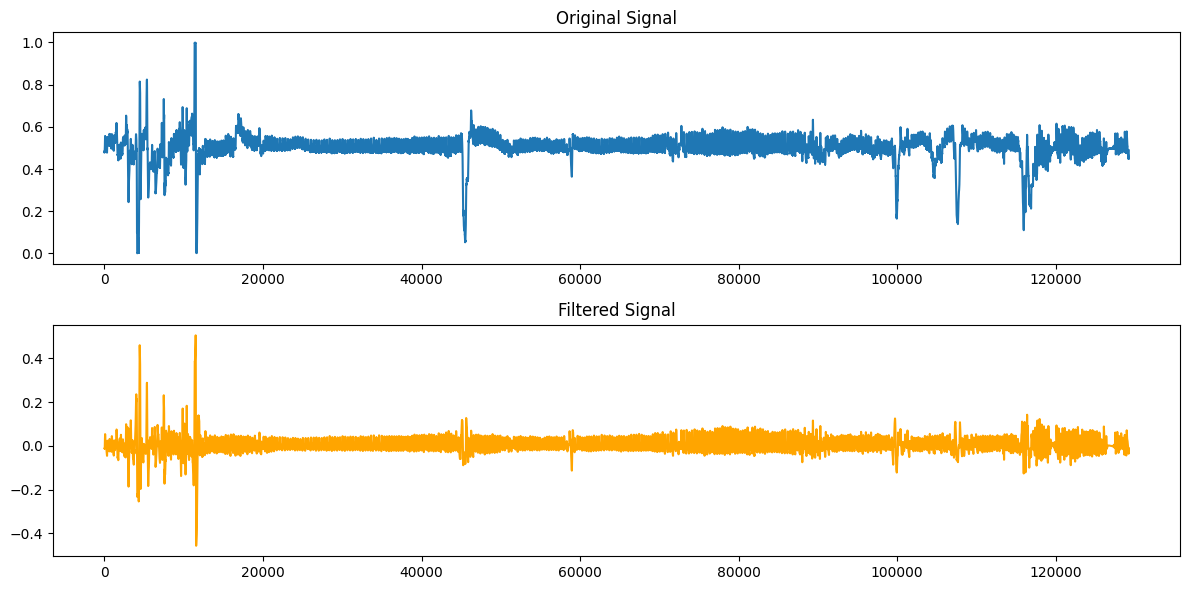

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 23.
Processing TASK for subject 23, Condition: HighFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-23\sub-23_ses-23_task-HighFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-23\sub-23_ses-23_task-HighFi\_.xdf.
Calculating task HRV for 23 (full file 1101.84s)...


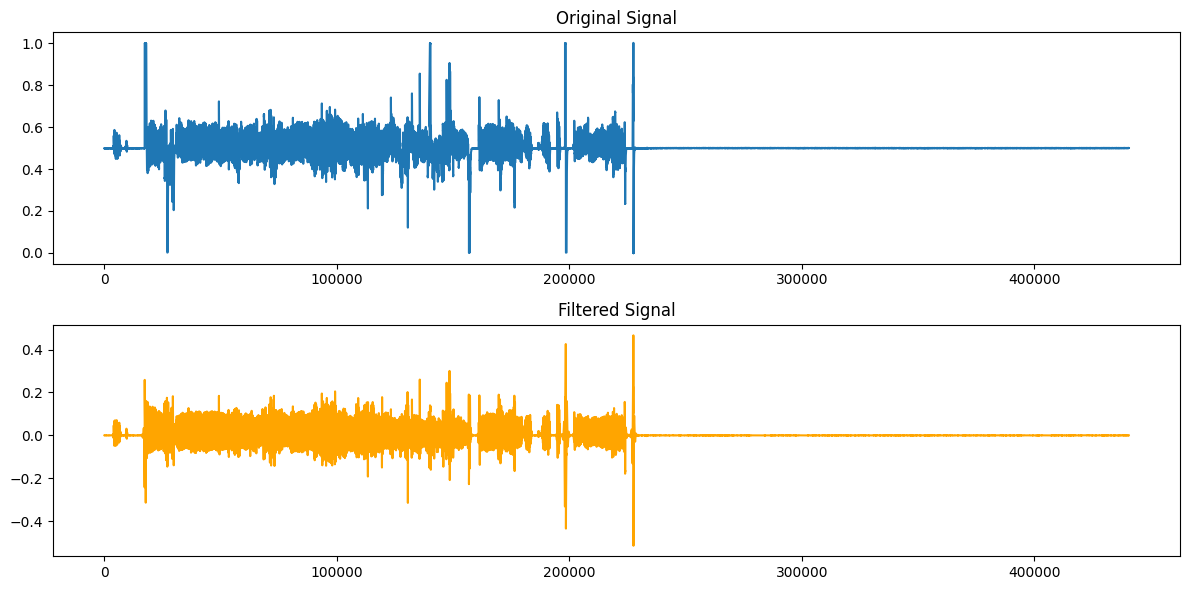

Task HRV calculated for 23.

Processing session: ses-24
  Found data for subjects in ses-24: ['sub-24']
    Processing data for subject key: sub-24 in session: ses-24
      Found Baseline file: _.xdf in folder sub-24_ses-24_task-Baseline
      Found Task Condition file: _.xdf in folder sub-24_ses-24_task-HighFi
      Pair found for 24: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 24 (Experimental Condition: HighFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-24\sub-24_ses-24_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-24\sub-24_ses-24_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-24\sub-24_ses-24_task-Baseline\_.xdf.
Calculating baseline HRV for 24 (full file)...


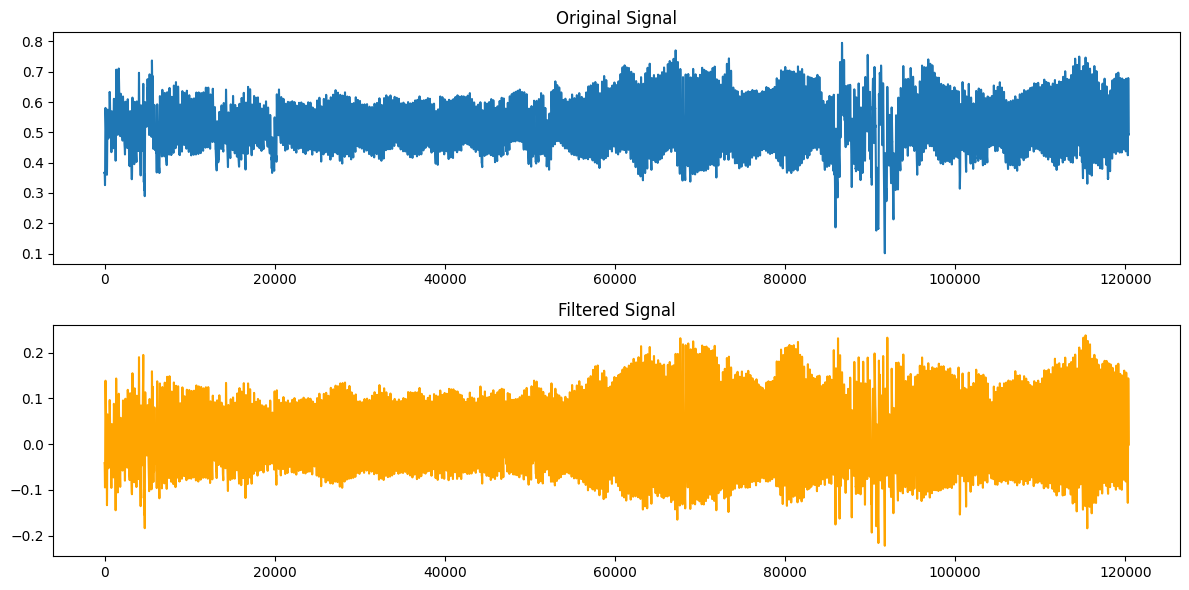

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 24.
Processing TASK for subject 24, Condition: HighFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-24\sub-24_ses-24_task-HighFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-24\sub-24_ses-24_task-HighFi\_.xdf.
Calculating task HRV for 24 (full file 433.28s)...


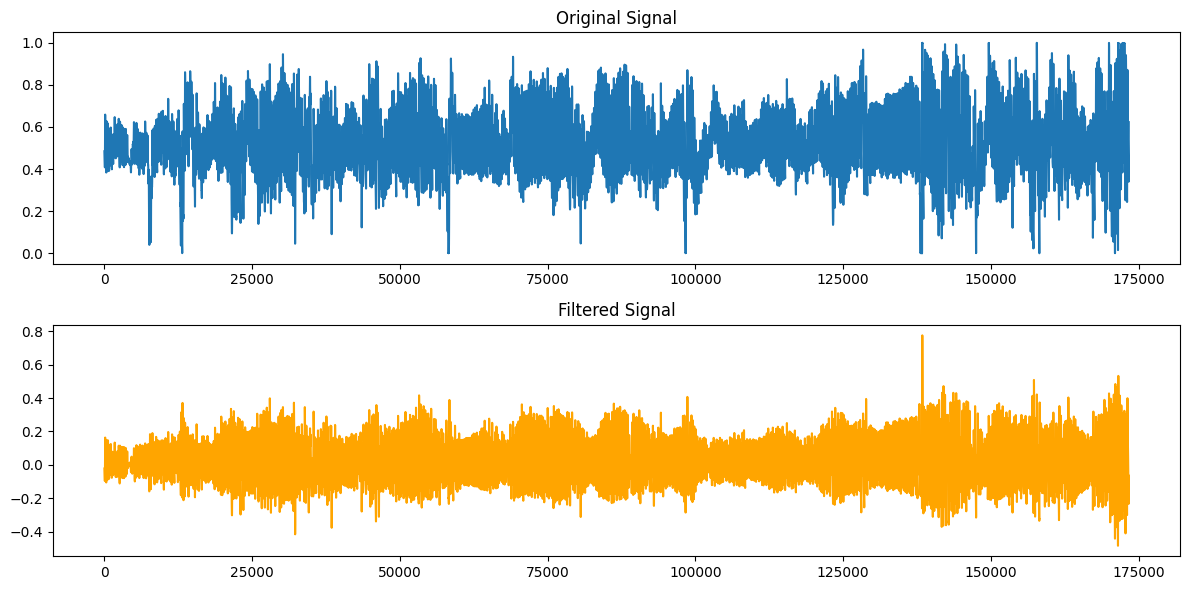

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\hrv\hrv_time.py:237: RuntimeWarning: Mean of empty slice
  avg_rri.append(np.nanmean(rri[start_idx:end_idx]))
c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Task HRV calculated for 24.

Processing session: ses-25
  Found data for subjects in ses-25: ['sub-25']
    Processing data for subject key: sub-25 in session: ses-25
      Found Baseline file: _.xdf in folder sub-25_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-25_ses-1_task-LowFi
      Pair found for 25: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 25 (Experimental Condition: LowFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-25\sub-25_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-25\sub-25_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-25\sub-25_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 25 (full file)...


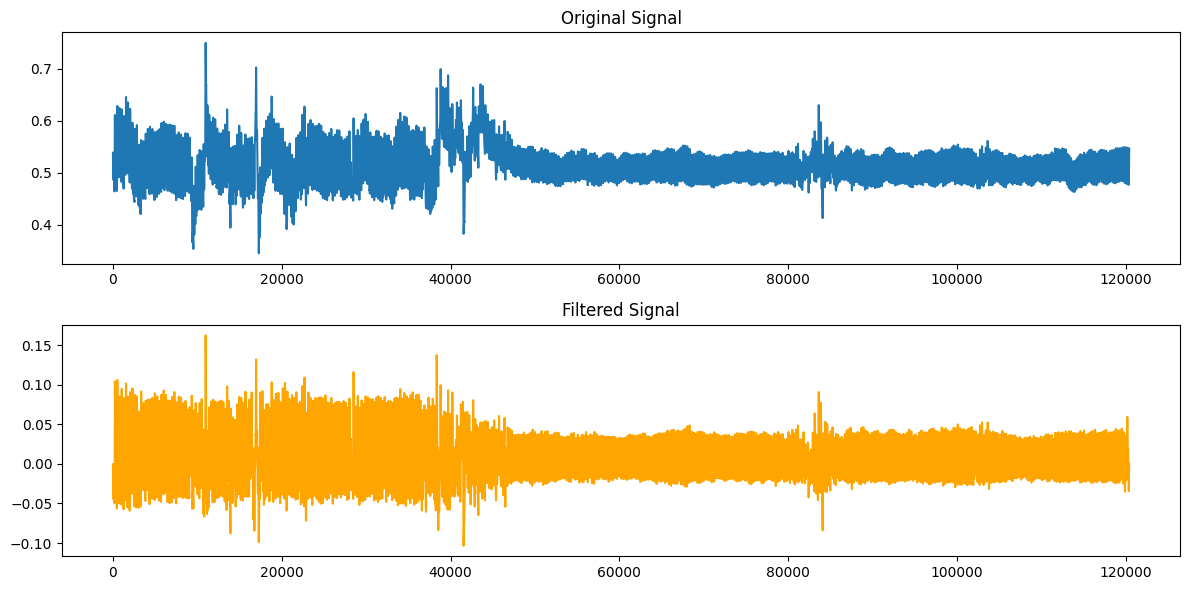

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 25.
Processing TASK for subject 25, Condition: LowFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-25\sub-25_ses-1_task-LowFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-25\sub-25_ses-1_task-LowFi\_.xdf.
Calculating task HRV for 25 (full file 486.00s)...


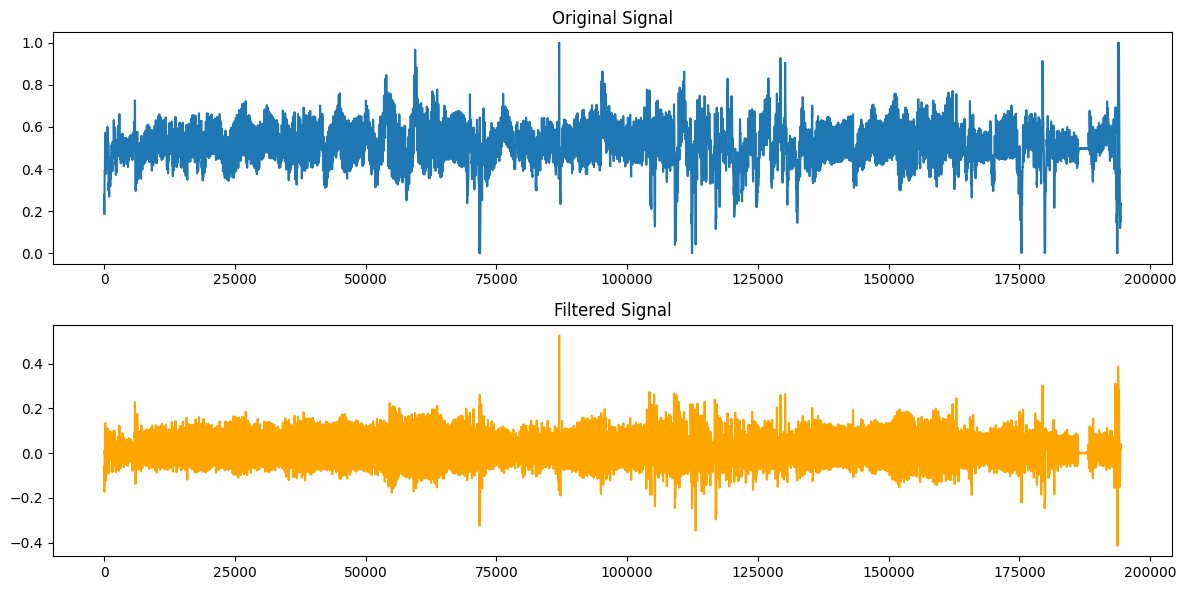

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 25.

Processing session: ses-26
  Found data for subjects in ses-26: ['sub-26']
    Processing data for subject key: sub-26 in session: ses-26
      Found Baseline file: _.xdf in folder sub-26_ses-1_task-Baseline
      Found Task Condition file: _.xdf in folder sub-26_ses-1_task-MediumFi
      Pair found for 26: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 26 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-26\sub-26_ses-1_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-26\sub-26_ses-1_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-26\sub-26_ses-1_task-Baseline\_.xdf.
Calculating baseline HRV for 26 (full file)...


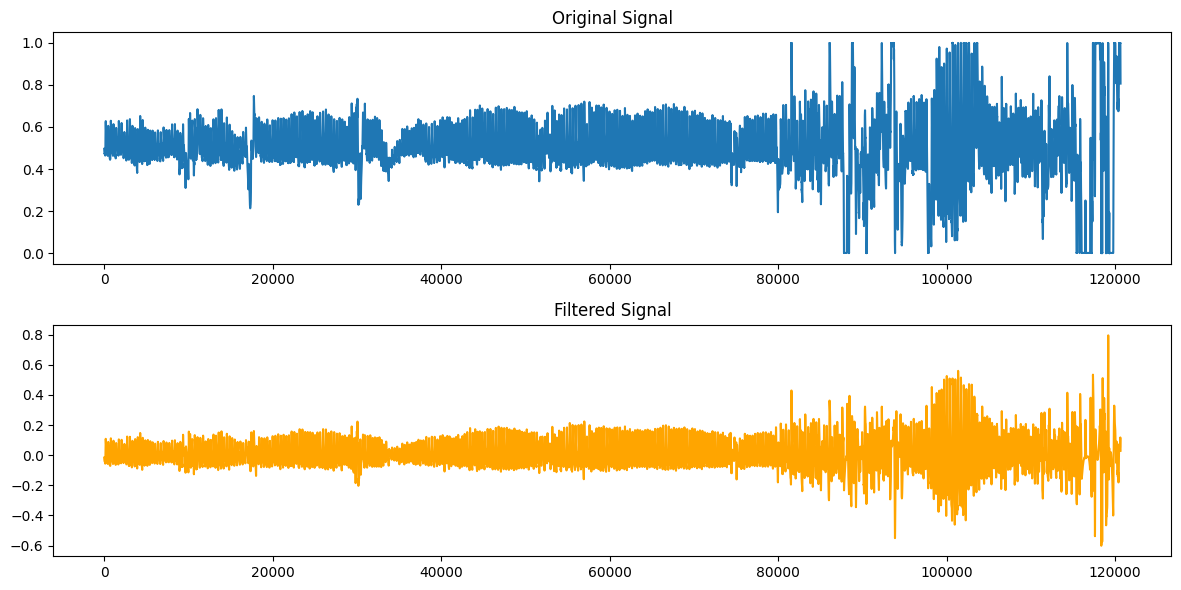

Baseline HRV calculated for 26.
Processing TASK for subject 26, Condition: MediumFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-26\sub-26_ses-1_task-MediumFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-26\sub-26_ses-1_task-MediumFi\_.xdf.
Calculating task HRV for 26 (full file 488.40s)...


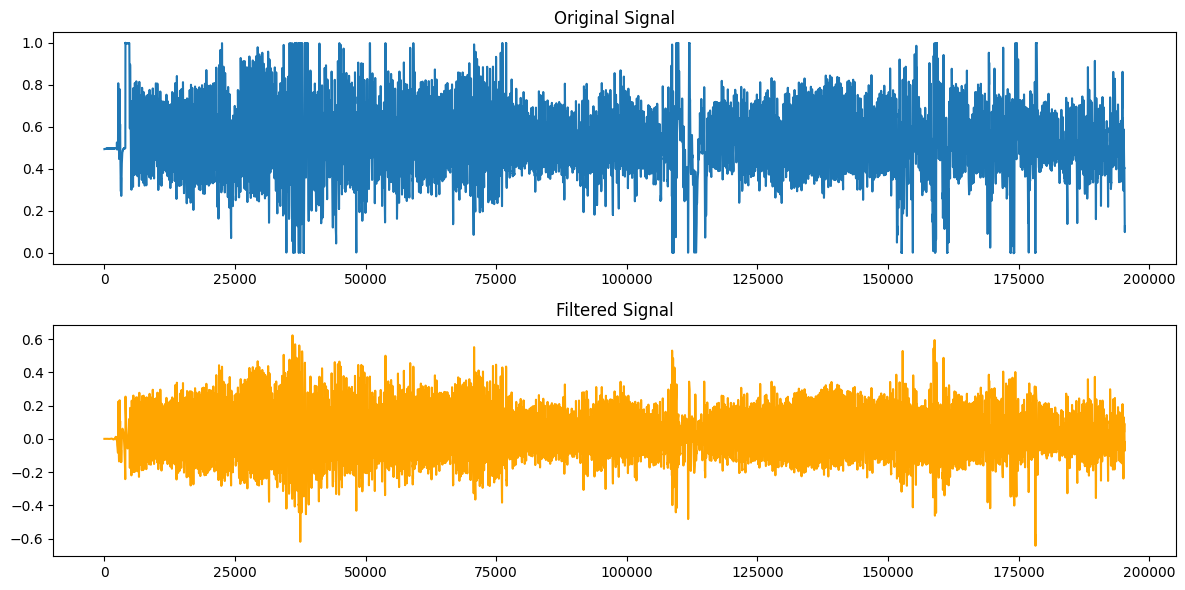

Task HRV calculated for 26.

Processing session: ses-27
  Found data for subjects in ses-27: ['sub-27']
    Processing data for subject key: sub-27 in session: ses-27
      Found Baseline file: _.xdf in folder sub-27_ses-27_task-Baseline
      Found Task Condition file: _.xdf in folder sub-27_ses-27_task-MediumFi
      Pair found for 27: Baseline (_.xdf), Task (_.xdf)
Processing BASELINE for subject 27 (Experimental Condition: MediumFi) from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-27\sub-27_ses-27_task-Baseline\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-27\sub-27_ses-27_task-Baseline\_.xdf.
UnityMarkers stream found in C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-27\sub-27_ses-27_task-Baseline\_.xdf.
Calculating baseline HRV for 27 (full file)...


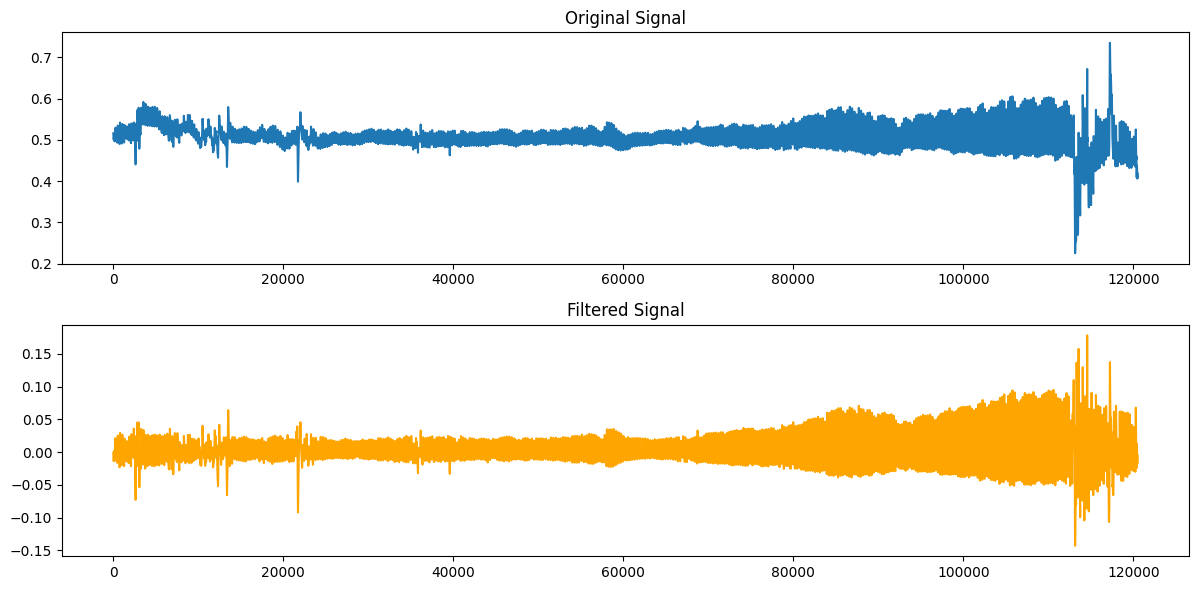

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Baseline HRV calculated for 27.
Processing TASK for subject 27, Condition: MediumFi from: _.xdf
Attempting to load XDF: C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-27\sub-27_ses-27_task-MediumFi\_.xdf
BVP stream found and BVP0 channel extracted from C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data\ses-27\sub-27_ses-27_task-MediumFi\_.xdf.
Calculating task HRV for 27 (full file 1016.64s)...


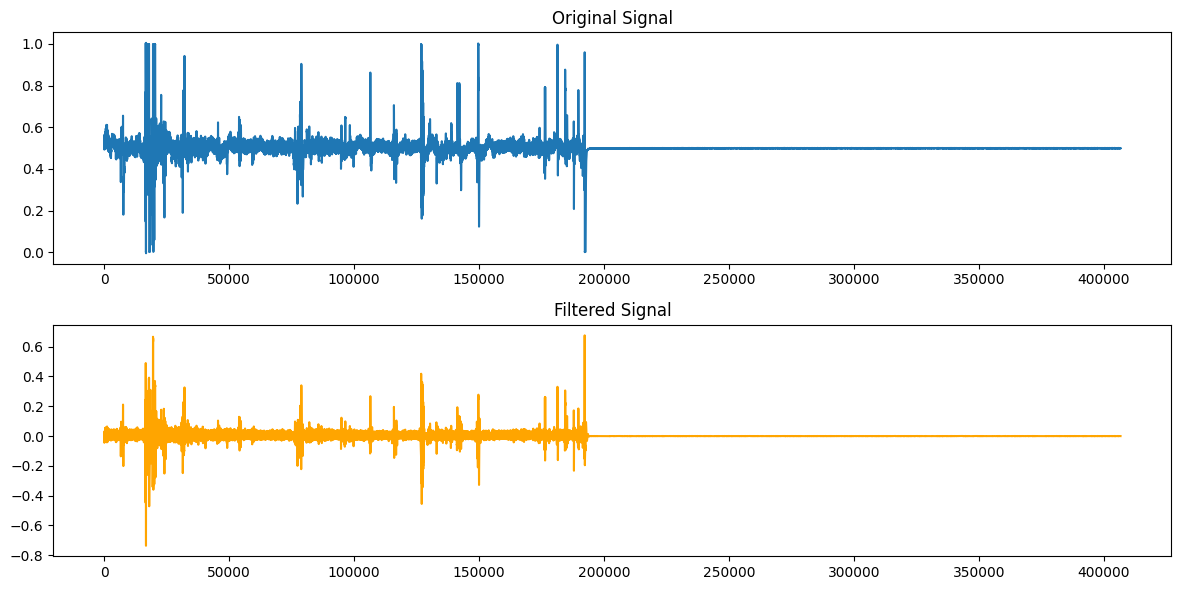

c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\neurokit2\signal\signal_interpolate.py:117: NeuroKitWarning: Duplicate x values detected. Averaging their corresponding y values.
  warn(


Task HRV calculated for 27.

--- Combined Results DataFrame ---
  ParticipantID Condition     Phase  HRV_MeanNN     HRV_SDNN  HRV_SDANN1  \
0             1    HighFi  Baseline  715.679284   226.257083   48.481917   
1             1    HighFi      Task  727.953191  1189.775585  273.490521   
2             2    HighFi  Baseline  565.038654    57.817954   16.013175   
3             2    HighFi      Task  620.542249   684.345599  130.463341   
4             3  MediumFi  Baseline  534.085485   168.454020   27.174945   

   HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  HRV_SDANN5  ...  HRV_SampEn  \
0  220.196165   40.496413  220.077430         NaN  ...    0.637484   
1  930.099612  110.209036  989.813782         NaN  ...    0.284032   
2   49.148874   19.703470   52.108503         NaN  ...    0.697417   
3  520.402667   51.503072  609.206616         NaN  ...    0.115508   
4  163.507260   19.632019  164.235590         NaN  ...    0.705434   

   HRV_ShanEn  HRV_FuzzyEn  HRV_MSEn  HRV_CMSEn  HRV_RCMSE

In [44]:
def filter_bvp(signal, lowcut=0.5, highcut=8.0, fs=400):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    if high <= low:
        print(f"Warning: Highcut frequency ({highcut}Hz) is not above lowcut frequency ({lowcut}Hz) at fs={fs}Hz. Adjusting filter or skipping.")
        return signal
    try:
        b, a = butter(4, [low, high], btype='bandpass')
        filtered = filtfilt(b, a, signal)
        # plot before and after filtering for debugging
        if debugging:
            plt.figure(figsize=(12, 6))
            plt.subplot(2, 1, 1)
            plt.plot(signal, label='Original Signal')
            plt.title('Original Signal')
            plt.subplot(2, 1, 2)
            plt.plot(filtered, label='Filtered Signal', color='orange')
            plt.title('Filtered Signal')
            plt.tight_layout()
            plt.show()
        return filtered
    except ValueError as ve:
        print(f"ValueError during filtering: {ve}. Returning unfiltered signal.")
        return signal

def get_hrv_metrics(bvp_segment, timestamps, fs=400):
    if len(bvp_segment) < fs * 10:
        print(f"Warning: Segment too short ({len(bvp_segment)/fs:.2f}s, need at least 10s), skipping HRV.")
        return pd.Series(dtype=float)
    try:
        filtered_segment = filter_bvp(bvp_segment, fs=fs)
        wd, m = hp.process(filtered_segment, sample_rate=fs, calc_freq=False, high_precision=True, clean_rr=True)
        peaks = wd.get('peaklist', [])
        if len(peaks) < 5:
            print(f"Warning: Not enough peaks found ({len(peaks)}, need at least 5), skipping HRV.")
            return pd.Series(dtype=float)
        # Ensure peak indices are integers and within bounds before indexing timestamps
        valid_peaks = []
        for p in peaks:
            try:
                p_int = int(p) # Convert to integer
                if 0 <= p_int < len(timestamps): # Check bounds
                    valid_peaks.append(p_int)
            except (ValueError, TypeError):
                print(f"Warning: Invalid peak value {p} encountered, skipping it.")

        if len(valid_peaks) < 2:
            print(f"Warning: Not enough valid peaks ({len(valid_peaks)}) after filtering and conversion. Original peaks count from heartpy: {len(peaks)}. Skipping HRV.")
            return pd.Series(dtype=float)
        peak_times_sec = timestamps[valid_peaks]
        ibi_ms = np.diff(peak_times_sec) * 1000
        if len(ibi_ms) < 3:
            print(f"Warning: Not enough IBIs calculated ({len(ibi_ms)}), skipping HRV.")
            return pd.Series(dtype=float)
        ibi_event_times_sec = peak_times_sec[1:]
        hrv_indices = nk.hrv({'RRI': ibi_ms, 'RRI_Time': ibi_event_times_sec}, sampling_rate=1000)
        return hrv_indices.iloc[0]
    except Exception as e:
        print(f"Error processing segment: {e}")
        return pd.Series(dtype=float)

def extract_bvp_and_markers_from_xdf(filepath):
    print(f"Attempting to load XDF: {filepath}")
    try:
        streams, header = pyxdf.load_xdf(filepath)
    except Exception as e:
        print(f"Error loading XDF file {filepath}: {e}")
        return None, None, pd.DataFrame(), {'bvp': False, 'markers': False}
    bvp_s = next((s for s in streams if s["info"]["name"][0] == "OpenSignals" and any(ch['label'][0] == 'BVP0' for ch in s['info']['desc'][0]['channels'][0]['channel'])), None)
    mark_s = next((s for s in streams if s["info"]["name"][0] == "UnityMarkers"), None)
    streams_found = {'bvp': False, 'markers': False}
    bvp_signal, bvp_ts = None, None
    df_events = pd.DataFrame()
    if bvp_s:
        bvp_data_raw = bvp_s['time_series']
        bvp_ts_raw = bvp_s['time_stamps']
        bvp_channel_idx = next((i for i, ch in enumerate(bvp_s['info']['desc'][0]['channels'][0]['channel']) if ch['label'][0] == 'BVP0'), None)
        if bvp_channel_idx is not None and bvp_data_raw.ndim == 2 and bvp_data_raw.shape[1] > bvp_channel_idx:
            bvp_signal = bvp_data_raw[:, bvp_channel_idx].astype(np.float64)
            bvp_ts = bvp_ts_raw
            streams_found['bvp'] = True
            print(f"BVP stream found and BVP0 channel extracted from {filepath}.")
        else:
            print(f"Warning: BVP0 channel not found or data format unexpected in OpenSignals stream for {filepath}.")
    else:
        print(f"Warning: BVP stream (OpenSignals with BVP0) not found in {filepath}.")
    if mark_s:
        markers_raw = mark_s['time_series']
        marker_ts_raw = mark_s['time_stamps']
        if len(markers_raw) > 0:
            df_events = pd.DataFrame({'time': marker_ts_raw, 'event': [m[0] for m in markers_raw]})
            streams_found['markers'] = True
            print(f"UnityMarkers stream found in {filepath}.")
        else:
            print(f"Warning: UnityMarkers stream found but no event data in {filepath}.")
    return bvp_signal, bvp_ts, df_events, streams_found

def process_subject_data(subject_id, baseline_filepath, task_filepath, nominal_srate=400):
    results_list = []
    condition_from_task_folder = "Unknown"  # Default

    # --- Determine Condition from Task File's PARENT FOLDER (if it exists) ---
    if task_filepath:
        task_parent_folder_name = os.path.basename(os.path.dirname(task_filepath))
        match_cond = re.search(r'_task-([^_\s]+)', task_parent_folder_name) # More robust regex for condition
        if match_cond:
            parsed_condition = match_cond.group(1)
            # Ensure 'Baseline' from folder name doesn't become the experimental condition
            if parsed_condition.lower() != 'baseline':
                condition_from_task_folder = parsed_condition
            else:
                print(f"Warning: Task filepath {task_filepath} seems to be from a folder named '...task-Baseline...'. Experimental condition remains 'Unknown' or will be based on a non-baseline task folder if available.")
        else:
            print(f"Warning: Could not parse condition from task folder name: {task_parent_folder_name} for subject {subject_id}")

    # --- 1. Process Baseline File ---
    if baseline_filepath:
        print(f"Processing BASELINE for subject {subject_id} (Experimental Condition: {condition_from_task_folder}) from: {os.path.basename(baseline_filepath)}")
        bvp_baseline, ts_baseline, df_events_baseline, streams_baseline = extract_bvp_and_markers_from_xdf(baseline_filepath)

        if streams_baseline['bvp'] and bvp_baseline is not None and ts_baseline is not None:
            print(f"Calculating baseline HRV for {subject_id} (full file)...")
            hrv_baseline_metrics = get_hrv_metrics(bvp_baseline, ts_baseline, fs=nominal_srate)
            if not hrv_baseline_metrics.empty:
                baseline_res = {'ParticipantID': subject_id, 'Condition': condition_from_task_folder, 'Phase': 'Baseline'}
                baseline_res.update(hrv_baseline_metrics)
                results_list.append(baseline_res)
                print(f"Baseline HRV calculated for {subject_id}.")
            else:
                print(f"No HRV metrics obtained for baseline for subject {subject_id}.")
        else:
            print(f"Could not process BVP for baseline for subject {subject_id} from {os.path.basename(baseline_filepath)}.")
    else:
        print(f"No baseline filepath provided for subject {subject_id}.")

    # --- 2. Process Task File ---
    if task_filepath:
        print(f"Processing TASK for subject {subject_id}, Condition: {condition_from_task_folder} from: {os.path.basename(task_filepath)}")
        bvp_task_full, ts_task_full, df_events_task, streams_task = extract_bvp_and_markers_from_xdf(task_filepath)

        if streams_task['bvp'] and bvp_task_full is not None and ts_task_full is not None:
            print(f"Calculating task HRV for {subject_id} (full file {len(bvp_task_full)/nominal_srate:.2f}s)...")
            hrv_task_metrics = get_hrv_metrics(bvp_task_full, ts_task_full, fs=nominal_srate)
            if not hrv_task_metrics.empty:
                task_res = {'ParticipantID': subject_id, 'Condition': condition_from_task_folder, 'Phase': 'Task'}
                task_res.update(hrv_task_metrics)
                results_list.append(task_res)
                print(f"Task HRV calculated for {subject_id}.")
            else:
                print(f"No HRV metrics obtained for task phase for subject {subject_id}.")
        else:
            print(f"Could not process BVP for task for subject {subject_id} from {os.path.basename(task_filepath)}.")
    else:
        print(f"No task filepath provided for subject {subject_id}.")

    return pd.DataFrame(results_list) if results_list else pd.DataFrame()

# --- Main Processing Loop ---
all_participant_dfs = [] 
data_root_folder = r"C:\Users\jacob\Documents\GitHub\P8-Project\Dataprocessing Pipeline\Test_Data"
nominal_srate_main = 400

session_folders = [f.path for f in os.scandir(data_root_folder) if f.is_dir() and re.match(r'ses-\d+', f.name)]
print(f"Found session folders: {session_folders}")

for session_folder_path in session_folders:
    session_name = os.path.basename(session_folder_path)
    print(f"\nProcessing session: {session_name}")

    potential_st_folders = [f.path for f in os.scandir(session_folder_path) if f.is_dir() and "_task-" in f.name and "sub-" in f.name]

    subject_folders_map = {}
    for st_folder_path in potential_st_folders:
        st_folder_name = os.path.basename(st_folder_path)
        match_sub = re.search(r'(sub-[^_\s]+)', st_folder_name)
        if match_sub:
            subject_id_key = match_sub.group(1)
            if subject_id_key not in subject_folders_map:
                subject_folders_map[subject_id_key] = []
            subject_folders_map[subject_id_key].append(st_folder_path)
        else:
            print(f"  Warning: Could not parse subject ID from folder name {st_folder_name} in session {session_name}.")

    print(f"  Found data for subjects in {session_name}: {list(subject_folders_map.keys())}")

    for subject_id_key, folders_for_subject in subject_folders_map.items():
        print(f"    Processing data for subject key: {subject_id_key} in session: {session_name}")

        baseline_filepath = None
        task_condition_filepath = None

        for folder_path in folders_for_subject:
            folder_name = os.path.basename(folder_path)
            xdf_files_in_folder = glob.glob(os.path.join(folder_path, "*.xdf"))

            if not xdf_files_in_folder:
                print(f"      Warning: No XDF file found in folder {folder_name}. Skipping this folder.")
                continue
            if len(xdf_files_in_folder) > 1:
                print(f"      Warning: Multiple XDF files found in {folder_name}. Using the first one: {os.path.basename(xdf_files_in_folder[0])}.")
            current_xdf_file = xdf_files_in_folder[0]

            if "_task-Baseline" in folder_name:
                if baseline_filepath:
                    print(f"      Warning: Multiple baseline folders/files found for {subject_id_key} in {session_name}. Overwriting with data from {folder_name}.")
                baseline_filepath = current_xdf_file
                print(f"      Found Baseline file: {os.path.basename(baseline_filepath)} in folder {folder_name}")
            elif "_task-" in folder_name:
                if task_condition_filepath:
                    print(f"      Warning: Multiple task condition folders/files found for {subject_id_key} in {session_name}. Overwriting with data from {folder_name}.")
                task_condition_filepath = current_xdf_file
                print(f"      Found Task Condition file: {os.path.basename(task_condition_filepath)} in folder {folder_name}")

        if baseline_filepath and task_condition_filepath:
            cleaned_subject_id = re.sub(r'^sub-', '', subject_id_key)
            print(f"      Pair found for {cleaned_subject_id}: Baseline ({os.path.basename(baseline_filepath)}), Task ({os.path.basename(task_condition_filepath)})")
            subject_hrv_df = process_subject_data(
                subject_id=cleaned_subject_id,
                baseline_filepath=baseline_filepath,
                task_filepath=task_condition_filepath,
                nominal_srate=nominal_srate_main
            )
            if not subject_hrv_df.empty:
                all_participant_dfs.append(subject_hrv_df)
            else:
                print(f"      No HRV data generated for subject {cleaned_subject_id} in session {session_name}.")
        else:
            missing_parts = []
            if not baseline_filepath: missing_parts.append("baseline file")
            if not task_condition_filepath: missing_parts.append("task condition file")
            print(f"      Skipping subject {subject_id_key} in session {session_name} due to missing { ' and '.join(missing_parts) }.")

if not all_participant_dfs:
    print("\nNo dataframes to concatenate. Final DataFrame will be empty.")
    final_df = pd.DataFrame()
else:
    final_df = pd.concat(all_participant_dfs, ignore_index=True)
    print("\n--- Combined Results DataFrame ---")
    if not final_df.empty:
        print(final_df.head())
    else:
        print("Final DataFrame is empty after processing all subjects.")

In [45]:
print(final_df)

   ParticipantID Condition     Phase  HRV_MeanNN     HRV_SDNN   HRV_SDANN1  \
0              1    HighFi  Baseline  715.679284   226.257083    48.481917   
1              1    HighFi      Task  727.953191  1189.775585   273.490521   
2              2    HighFi  Baseline  565.038654    57.817954    16.013175   
3              2    HighFi      Task  620.542249   684.345599   130.463341   
4              3  MediumFi  Baseline  534.085485   168.454020    27.174945   
5              3  MediumFi      Task  579.257756   291.470507    23.792630   
6              4    HighFi  Baseline  546.104511    71.196034    14.995208   
7              4    HighFi      Task  539.913706    63.052132     7.936986   
8              5    HighFi      Task  728.391420  1377.793085    35.635797   
9              6  MediumFi  Baseline  720.362129   343.066159    74.287398   
10             6  MediumFi      Task  708.597926  1232.896508   363.475236   
11             7     LowFi  Baseline  778.079340  1238.519766   

## Statistical Modeling\n
\n
We now have a DataFrame (`final_df`) containing HRV metrics for each participant, condition, and phase. We can use this to perform a mixed-design analysis.\n
\n
A Linear Mixed-Effects Model (LMM) is suitable here. It allows us to model:\n
- **Fixed Effects:** The average effects of `Phase` (Baseline vs. Task) and `Condition` (LowFi, MedFi, HighFi), and their interaction (`Phase * Condition`).\n
- **Random Effects:** The variability between participants. We assume each participant has their own baseline level of the HRV metric, modeled as a random intercept (`1|ParticipantID`).\n
\n
We will model one HRV metric at a time, for example, RMSSD (Root Mean Square of Successive Differences).

In [46]:
import statsmodels.formula.api as smf

# Check if final_df exists and has data
if 'final_df' in locals() and not final_df.empty and 'HRV_RMSSD' in final_df.columns:
    # Ensure necessary columns are not all NaN
    if final_df[['HRV_RMSSD', 'Phase', 'Condition', 'ParticipantID']].isnull().all().any():
        print("Warning: One or more critical columns contain only NaN values. Cannot run model.")
    else: 
        # Remove rows with NaN in the outcome variable or predictors
        model_df = final_df.dropna(subset=['HRV_RMSSD', 'Phase', 'Condition', 'ParticipantID'])
        
        if model_df.empty:
            print("Warning: No valid data remaining after removing NaNs. Cannot run model.")
        else:
            print("\n--- Inspecting model_df before fitting LMM ---")
            print(model_df.info())

            # Print a few rows to see actual values
            print("\n--- Fitting Linear Mixed-Effects Model for HRV_RMSSD ---")
            # Ensure ParticipantID, Phase, and Condition are appropriate types
            model_df['ParticipantID'] = model_df['ParticipantID'].astype('category')
            model_df['Phase'] = model_df['Phase'].astype('category')
            model_df['Condition'] = model_df['Condition'].astype('category')
            
            # Define the model formula for fixed effects
            fixed_effects_formula = "HRV_RMSSD ~ C(Phase) * C(Condition)"
            # Define the random effects formula (random intercept for ParticipantID)
            random_effects_formula = "~1"
            
            try:
                # Fit the model using re_formula for random effects
                model = smf.mixedlm(fixed_effects_formula, 
                                  model_df, 
                                  groups=model_df["ParticipantID"], 
                                  re_formula=random_effects_formula)
                result = model.fit()
                
                # Print the summary
                print(result.summary())
            except Exception as e:
                print(f"Error fitting model: {e}")
                print("\nPlease check data structure and variability.")
                print("Model DataFrame head:")
                print(model_df.head())
else:
    print("Skipping statistical analysis: 'final_df' not created or is empty or missing 'HRV_RMSSD' column.")


--- Inspecting model_df before fitting LMM ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 94 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ParticipantID                 42 non-null     object 
 1   Condition                     42 non-null     object 
 2   Phase                         42 non-null     object 
 3   HRV_MeanNN                    42 non-null     float64
 4   HRV_SDNN                      42 non-null     float64
 5   HRV_SDANN1                    42 non-null     float64
 6   HRV_SDNNI1                    42 non-null     float64
 7   HRV_SDANN2                    38 non-null     float64
 8   HRV_SDNNI2                    38 non-null     float64
 9   HRV_SDANN5                    0 non-null      float64
 10  HRV_SDNNI5                    0 non-null      float64
 11  HRV_RMSSD                     42 non-null     float64
 12  HRV_SDSD          

## Interpretation (Example for RMSSD)\n
\n
Look at the model summary table:\n
- **Intercept:** Estimated RMSSD for the reference group (e.g., Baseline phase in the LowFi condition, depending on how statsmodels encodes categories).\n
- **C(Phase)[T.Task]:** The estimated average *change* in RMSSD when moving from Baseline to Task phase (holding Condition constant at the reference level).\n
- **C(Condition)[T.MedFi/HighFi]:** The estimated average *difference* in RMSSD between MedFi/HighFi and the reference condition (LowFi) during the reference phase (Baseline).\n
- **C(Phase)[T.Task]:C(Condition)[T.MedFi/HighFi]:** The interaction effect. This shows how the *effect of Phase* (Task vs. Baseline) differs between the MedFi/HighFi conditions compared to the LowFi condition. A significant interaction suggests the task effect depends on the fidelity level.\n
- **P>|z|:** The p-value for each coefficient. Values < 0.05 typically indicate statistical significance.\n
- **Group Var:** The variance of the random intercepts, indicating how much baseline RMSSD varies between participants.\n
\n
*Note: You would repeat the modeling step for other HRV metrics of interest (e.g., SDNN, MeanNN, pNN50) by changing the dependent variable in the formula.*

### Butterworth Bandpass Filter

A butterworth filter is a commonly used filter when handling ECG signals, as it helps remove high frequency noise. The equation for the for a Butterworth Filter is given by:
$$
    G(w) = \frac{1}{\sqrt{1+w^2n}}
$$

Where $w$ is the angular frequency in radiants per second and $n$ is the number of poles in the filter. This can be modified into a bandpass filter to look like: 
$$
    G_{BP}(w) = \frac{1}{\sqrt{1+(\frac{B(w^2-w_0^2)}{ww_0})^{2n}}}
$$
Here $w_0 = \sqrt{w_Lw_H}$ as the low and high frequency cutoffs, and $B = w_H - w_L$ being the bandwidth.

## IEQ

In [47]:
def calculate_omega(data):
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(data)
    loadings = fa.loadings_[:, 0]
    uniquenesses = fa.get_uniquenesses()
    numerator = np.sum(loadings)**2
    denominator = numerator + np.sum(uniquenesses)
    return numerator / denominator

# score meaning is (Source: Steiner, 2003, p102)
def interpret_omega(score):
    if score > 0.9:
        return "Excellent"
    elif 0.7 <= score <= 0.9:
        return "Good"
    elif 0.6 <= score < 0.7:
        return "Acceptable"
    elif 0.5 <= score < 0.6:
        return "Poor"
    else:
        return "Unacceptable"

def testing_for_assumptions_by_group(df, score_col="IEQ Score", group_col="Group"):
    print(f"# Testing assumptions for {score_col} #\n")

    groups = df[group_col].unique()
    group_data = {g: df[df[group_col] == g][score_col].dropna() for g in groups}

    # 1. Shapiro–Wilk Test for Normality
    print("## Shapiro–Wilk Test for Normality ##")
    normality = {}
    for group, data in group_data.items():
        print(f"Group {group}:")
        if len(data) < 3:
            print(f"  ⚠️ Not enough data (n={len(data)}) to test normality.\n")
            normality[group] = False
            continue
        stat, p = shapiro(data)
        normal = p > 0.05
        normality[group] = normal
        if normal:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Data appears normal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Data not normal\n")

    print("## Levene’s Test for Equal Variances ##")
    data_lists = [d for d in group_data.values() if len(d) >= 2]
    if len(data_lists) >= 2:
        stat, p = levene(*data_lists)
        equal_var = p > 0.05
        if equal_var:
            print(f"  ✔️ Stat = {stat:.4f}, p = {p:.4f} → Variances are equal\n")
        else:
            print(f"  ❌ Stat = {stat:.4f}, p = {p:.4f} → Variances are not equal\n")
    else:
        equal_var = False
        print("  ⚠️ Not enough groups with sufficient data to test variance\n")

    print(f"# Final Group Comparison Test for {score_col} #")
    normal_all = all(normality.values())
    sufficient_groups = len([group_data[g] for g in groups if len(group_data[g]) >= 2]) > 2
    if normal_all and equal_var:
        print("✅ All assumptions met. Running ANOVA:")
        if(sufficient_groups):
            stat, p = f_oneway(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ ANOVA Stat = {stat:.4f}, p = {p:.4f}")
    else:
        print("❌ Assumptions not met. Using non-parametric Kruskal–Wallis:")
        if(sufficient_groups):
            stat, p = kruskal(*[group_data[g] for g in groups if len(group_data[g]) >= 2])
            print(f"  ✔️ Kruskal–Wallis Stat = {stat:.4f}, p = {p:.4f}")

post_path = glob.glob("Qustionare_data\Post\*.xlsx")[0]
##print(post_path)
df_post = pd.read_excel(post_path, sheet_name=0)
##df_post

In [48]:
questions_df = df_post.iloc[:, 8:39].copy()
questions_df = questions_df.apply(pd.to_numeric, errors='coerce')

questions_to_reverse_indices = [5, 7, 9, 17, 19]
for index in questions_to_reverse_indices:
    column_name = questions_df.columns[index]
    questions_df[column_name] = 8 - questions_df[column_name]

IEQ_scores_list = questions_df.sum(axis=1, skipna=True)
IEQ_scores = pd.DataFrame({
    "IEQ Score": IEQ_scores_list,
    "Participant Number": df_post.iloc[:, 6].values,
    "Group": df_post.iloc[:, 7].values,
    "Single Question Measure of Immersion": df_post.iloc[:, 39].values
})

omega_ieq = calculate_omega(questions_df)
print(f"The reliability of the IEQ was {interpret_omega(omega_ieq)}, with a McDonald's Omega (TLX combined) = {omega_ieq:.3f}")
IEQ_scores

The reliability of the IEQ was Good, with a McDonald's Omega (TLX combined) = 0.775


c:\Users\jacob\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,IEQ Score,Participant Number,Group,Single Question Measure of Immersion
0,173,1,Group C,7
1,137,2,Group C,6
2,161,3,Group B,10
3,163,4,Group C,7
4,172,5,Group C,9
5,161,6,Group B,8
6,171,7,Group A,7
7,159,8,Group C,9
8,166,9,Group B,8
9,167,10,Group B,7


In [49]:
IEQ_scores.describe()

,IEQ Score,Participant Number,Single Question Measure of Immersion
count,27.000000,27.000000,27.000000
mean,162.185185,14.000000,7.481481
std,13.079747,7.937254,1.220667
min,137.000000,1.000000,5.000000
25%,156.000000,7.500000,7.000000
50%,161.000000,14.000000,7.000000
75%,172.500000,20.500000,8.000000
max,184.000000,27.000000,10.000000


In [50]:
testing_for_assumptions_by_group(IEQ_scores, score_col="IEQ Score", group_col="Group")

# Testing assumptions for IEQ Score #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.9141, p = 0.3459 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9320, p = 0.4681 → Data appears normal

Group Group A:
  ✔️ Stat = 0.9139, p = 0.3822 → Data appears normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.1314, p = 0.8775 → Variances are equal

# Final Group Comparison Test for IEQ Score #
✅ All assumptions met. Running ANOVA:
  ✔️ ANOVA Stat = 0.7925, p = 0.4642


In [51]:
testing_for_assumptions_by_group(IEQ_scores, score_col="Single Question Measure of Immersion", group_col="Group")

# Testing assumptions for Single Question Measure of Immersion #

## Shapiro–Wilk Test for Normality ##
Group Group C:
  ✔️ Stat = 0.8838, p = 0.1719 → Data appears normal

Group Group B:
  ✔️ Stat = 0.9337, p = 0.4851 → Data appears normal

Group Group A:
  ❌ Stat = 0.6756, p = 0.0012 → Data not normal

## Levene’s Test for Equal Variances ##
  ✔️ Stat = 0.6812, p = 0.5155 → Variances are equal

# Final Group Comparison Test for Single Question Measure of Immersion #
❌ Assumptions not met. Using non-parametric Kruskal–Wallis:
  ✔️ Kruskal–Wallis Stat = 1.7248, p = 0.4221


In [52]:
# Extract data for each group
group_a = IEQ_scores[IEQ_scores["Group"] == "Group A"]["IEQ Score"]
group_b = IEQ_scores[IEQ_scores["Group"] == "Group B"]["IEQ Score"]
group_c = IEQ_scores[IEQ_scores["Group"] == "Group C"]["IEQ Score"]

print("#Low fi group: ")
print(group_a.describe())

#Low fi group: 
count      8.000000
mean     160.500000
std       13.835771
min      144.000000
25%      152.250000
50%      157.000000
75%      172.000000
max      181.000000
Name: IEQ Score, dtype: float64


In [53]:
print("#Low mid group: ")
print(group_b.describe())

#Low mid group: 
count     10.000000
mean     159.500000
std       11.768602
min      137.000000
25%      155.250000
50%      161.000000
75%      166.750000
max      174.000000
Name: IEQ Score, dtype: float64


In [54]:
print("#Low hi group: ")
print(group_c.describe())

#Low hi group: 
count      9.000000
mean     166.666667
std       14.080128
min      137.000000
25%      159.000000
50%      172.000000
75%      174.000000
max      184.000000
Name: IEQ Score, dtype: float64


SS stands for Sum of Squares
SS_between: 275.5741
SS_within: 4172.5000
SS_total: 4448.0741
Effect Size (Eta Squared, η²): 0.0620
ANOVA Results: F-statistic = 0.7925, p-value = 0.4642
No significant difference between the groups.


C:\Users\jacob\AppData\Local\Temp\ipykernel_19292\926922712.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)


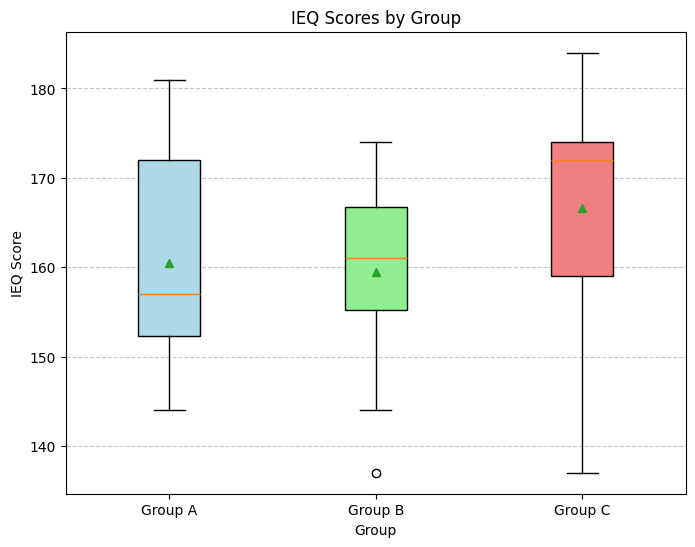

In [55]:
# Combine all groups into one dataset
all_data = pd.concat([group_a, group_b, group_c])
grand_mean = all_data.mean()

# Calculate Sum of Squares Between (SS_between)
n_a, n_b, n_c = len(group_a), len(group_b), len(group_c)
mean_a, mean_b, mean_c = group_a.mean(), group_b.mean(), group_c.mean()
SS_between = n_a * (mean_a - grand_mean)**2 + n_b * (mean_b - grand_mean)**2 + n_c * (mean_c - grand_mean)**2

# Calculate Sum of Squares Within (SS_within)
SS_within = sum((group_a - mean_a)**2) + sum((group_b - mean_b)**2) + sum((group_c - mean_c)**2)

# Calculate Total Sum of Squares (SS_total)
SS_total = SS_between + SS_within

# Calculate Eta Squared (η²)
eta_squared = SS_between / SS_total

# Print results
print("SS stands for Sum of Squares")
print(f"SS_between: {SS_between:.4f}")
print(f"SS_within: {SS_within:.4f}")
print(f"SS_total: {SS_total:.4f}")
print(f"Effect Size (Eta Squared, η²): {eta_squared:.4f}")

# Perform one-way ANOVA
stat, p = f_oneway(group_a, group_b, group_c)
print(f"ANOVA Results: F-statistic = {stat:.4f}, p-value = {p:.4f}")
if p < 0.05:
    print("There is a significant difference between the groups.")
else:
    print("No significant difference between the groups.")

# Plot the scores for each group
plt.figure(figsize=(8, 6))
data = [group_a, group_b, group_c]
boxplot = plt.boxplot(data, labels=["Group A", "Group B", "Group C"], patch_artist=True, showmeans=True)
plt.title("IEQ Scores by Group")

# Assign different colors to each group
colors = ['lightblue', 'lightgreen', 'lightcoral']
for box, color in zip(boxplot['boxes'], colors):
    box.set_facecolor(color)

plt.ylabel("IEQ Score")
plt.xlabel("Group")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [56]:
print("Welch's ANOVA Results")
pg.welch_anova(dv='IEQ Score', between='Group', data=IEQ_scores) 

Welch's ANOVA Results


,Source,ddof1,ddof2,F,p-unc,np2
0,Group,2,15.242619,0.731881,0.497162,0.061954


In [57]:
from scipy.stats import ttest_ind
# Group A vs Group C
stat_ac, p_ac = ttest_ind(group_c, group_b, equal_var=True)  # Use equal_var=True if variances are equal
print(f"Group A vs Group C: t-statistic = {stat_ac:.4f}, one-tailed p-value = {p_ac:.4f}")
# Group A vs Group B
stat_bc, p_bc = ttest_ind(group_c, group_b, equal_var=True)
print(f"Group B vs Group C: t-statistic = {stat_bc:.4f}, one-tailed p-value = {p_bc:.4f}")

Group A vs Group C: t-statistic = 1.2084, one-tailed p-value = 0.2434
Group B vs Group C: t-statistic = 1.2084, one-tailed p-value = 0.2434


In [63]:
threshold = 31 
singleQuestionScalingFactor = 21.7 # (217 - 31)/10

# Calculate the absolute difference between the Single Question score and the IEQ Score
IEQ_scores["Difference"] = abs(IEQ_scores["Single Question Measure of Immersion"] * 21.7 - IEQ_scores["IEQ Score"])

# Identify rows where the difference exceeds the threshold
outliers_df = IEQ_scores[IEQ_scores["Difference"] > threshold]

# Print the outliers
print("Outliers based on the difference between Single Question and IEQ Score:")
print(outliers_df)

# Optionally, drop the outliers from the original DataFrame
filtered_df = IEQ_scores[IEQ_scores["Difference"] <= threshold]
print(filtered_df.describe())
filtered_df

Outliers based on the difference between Single Question and IEQ Score:
    IEQ Score ParticipantID    Group  Single Question Measure of Immersion  \
2         161             3  Group B                                    10   
7         159             8  Group C                                     9   
10        181            11  Group A                                    10   

    Difference  
2         56.0  
7         36.3  
10        36.0  
        IEQ Score  Single Question Measure of Immersion  Difference
count   24.000000                             24.000000   24.000000
mean   161.583333                              7.208333   14.654167
std     13.308764                              0.977093    8.904175
min    137.000000                              5.000000    0.400000
25%    154.750000                              7.000000    7.475000
50%    162.000000                              7.000000   14.450000
75%    172.250000                              8.000000   21.600000
max

,IEQ Score,ParticipantID,Group,Single Question Measure of Immersion,Difference
0,173,1,Group C,7,21.1
1,137,2,Group C,6,6.8
3,163,4,Group C,7,11.1
4,172,5,Group C,9,23.3
5,161,6,Group B,8,12.6
6,171,7,Group A,7,19.1
8,166,9,Group B,8,7.6
9,167,10,Group B,7,15.1
11,144,12,Group B,6,13.8
12,144,13,Group A,7,7.9


In [ ]:
# Ensure ParticipantID in both DataFrames is of the same type
filtered_df.rename(columns={'ParticipantID': 'ParticipantID'}, inplace=True)
filtered_df['ParticipantID'] = filtered_df['ParticipantID'].astype(str)
final_df['ParticipantID'] = final_df['ParticipantID'].astype(str)

# Merge the DataFrames on ParticipantID
merged_df = pd.merge(final_df, filtered_df[['ParticipantID', 'IEQ Score']], on='ParticipantID', how='left')

# Display the merged DataFrame
print(merged_df)

   ParticipantID Condition     Phase  HRV_MeanNN     HRV_SDNN   HRV_SDANN1  \
0              1    HighFi  Baseline  715.679284   226.257083    48.481917   
1              1    HighFi      Task  727.953191  1189.775585   273.490521   
2              2    HighFi  Baseline  565.038654    57.817954    16.013175   
3              2    HighFi      Task  620.542249   684.345599   130.463341   
4              3  MediumFi  Baseline  534.085485   168.454020    27.174945   
5              3  MediumFi      Task  579.257756   291.470507    23.792630   
6              4    HighFi  Baseline  546.104511    71.196034    14.995208   
7              4    HighFi      Task  539.913706    63.052132     7.936986   
8              5    HighFi      Task  728.391420  1377.793085    35.635797   
9              6  MediumFi  Baseline  720.362129   343.066159    74.287398   
10             6  MediumFi      Task  708.597926  1232.896508   363.475236   
11             7     LowFi  Baseline  778.079340  1238.519766   

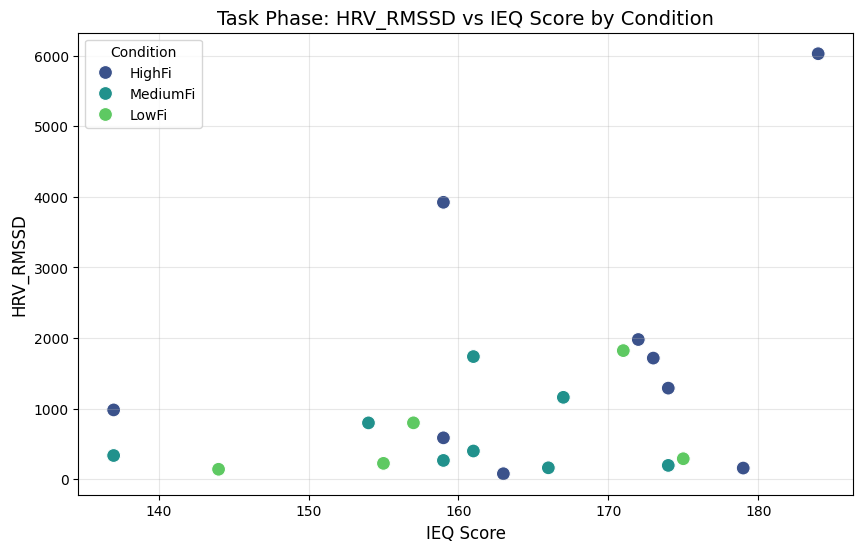

In [61]:
# Filter the data for the Task phase
task_phase_data = merged_df[merged_df['Phase'] == 'Task']

# Check if the necessary columns exist and are not empty
if not task_phase_data.empty and 'HRV_RMSSD' in task_phase_data.columns and 'IEQ Score' in task_phase_data.columns:
    plt.figure(figsize=(10, 6))
    
    # Create a scatter plot with seaborn
    sns.scatterplot(
        data=task_phase_data,
        x='IEQ Score',
        y='HRV_RMSSD',
        hue='Condition',
        palette='viridis',
        s=100
    )
    
    # Add labels and title
    plt.title('Task Phase: HRV_RMSSD vs IEQ Score by Condition', fontsize=14)
    plt.xlabel('IEQ Score', fontsize=12)
    plt.ylabel('HRV_RMSSD', fontsize=12)
    plt.legend(title='Condition', fontsize=10)
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("The data for the Task phase is empty or missing required columns.")